## import packages

In [2]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import pandas as pd # for creation of data frames
import numpy as np #
import pyls # PLS: behavioral and mean-centered
import seaborn as sns
import nibabel as nib # for loading niftis etc. as arrays
import matplotlib.pyplot as plt # for plotting data
from matplotlib import cm
#the output of plotting commands is displayed inline, directly below the code cell thatf produced it
%matplotlib inline 
import os,glob
from nilearn import plotting, input_data, image #for plotting & working with niftis
from nilearn import surface
from nilearn import datasets
fsaverage = datasets.fetch_surf_fsaverage()
from scipy import stats
from nilearn import glm
import pathlib
from pathlib import Path

###################### update path!! #####################################
###################### update path!! #####################################
base_path = 'DATAPATH' 
script_path = 'SCRIPT_PATH' 
cmrglcpath = 'CMRGLC_PATH'
##########################################################################

#import qBOLD functions
#import sys
#sys.path.append(os.path.join(base_path + 'scripts/'))
#import mqBOLD_functions as qB

os.environ["FSLOUTPUTTYPE"]='NIFTI_GZ'
os.environ["FSLDIR"] = "/opt/fsl/6.0.7.16"
os.environ["ANTSPATH"] = '/opt/ants/bin'
os.environ["PATH"] += f':{os.environ["ANTSPATH"]}'
os.environ["LD_LIBRARY_PATH"] += ':/opt/ants/lib'


#define ANTS directories
os.environ["ANTSPATH"] = '/opt/ants/bin'
os.environ["PATH"] = f'{os.environ["ANTSPATH"]}:{os.environ["PATH"]}'
if "LD_LIBRARY_PATH" in os.environ:
    os.environ["LD_LIBRARY_PATH"] = f'/opt/ants/lib:{os.environ["LD_LIBRARY_PATH"]}'
else:
    os.environ["LD_LIBRARY_PATH"] = '/opt/ants/lib'

## define variables (please check!!)

In [3]:
data_dir = base_path + '/data'
derivatives_dir = data_dir + '/derivatives'
results_dir = data_dir + '/results'

MNI_2mm_brain = os.path.join(script_path, 'mni_MNI2009aNLinAysm_2mm_brain.nii.gz')
MNI_2mm = os.path.join(script_path, 'mni_MNI2009aNLinAysm_2mm.nii.gz')


sids_overlap = [1, 4, 7, 10, 11, 14, 15, 16, 17, 18, 19, 10] ## N=12, These subjects have both CMRglc and CMRO2
sids=[ 1, 2,  4, 7, 10,11,14, 15, 16, 17, 18, 19, 20 ] ##N=13, only non-pilot data, but including 10!
sids_cmrglc =[ 1, 3,4, 7, 9,10,11, 13,14, 15, 16, 17, 18, 19, 20 ] ## N=15
sids_all = [ 1, 2, 3,4, 7, 9,10,11, 13,14, 15, 16, 17, 18, 19, 20  ] 
sids_cbv = [4, 7, 10, 11, 14, 15, 16, 17, 18, 19, 20 ]

conds = [ 'open', 'checker']

sns.set_style("whitegrid")

coords=(-15, 0, 15, 30, 45, 60, 75, 90)


#######################
## please choose ######
#######################

#CBV_masking='yes'
CBV_masking='no'

#######################

if CBV_masking == 'yes':
    ## kick out voxels with CBV > 5.5, plus voxels with low SNR and GM probability < 0.5
    GM_SNR_mask = os.path.join(derivatives_dir, 'N16_space-MNI152_SNR_YEO_CBV_mask.nii.gz')
if CBV_masking == 'no':
    ## leave in all voxels with CBV, only kick out voxles with low SNR and GM probability < 0.5
    GM_SNR_mask = os.path.join(derivatives_dir, 'task-loc_space-MNI152NLin6Asym_res-2_SNR_YEO_group_mask.nii.gz')
    
    
##Yeo's visual network
visual = os.path.join(derivatives_dir, 'Yeo2011_17Networks_MNI152_FreeSurferConformed2mm_MNI_visual.nii.gz')

## define blue-red colorbar

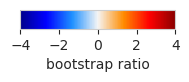

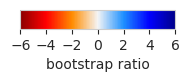

In [4]:
import matplotlib as mpl
sns.set_style("whitegrid")
from matplotlib.colors import LinearSegmentedColormap

colors = ["darkblue", "blue", "dodgerblue",  "whitesmoke","darkorange", "red", "darkred"]
BlueRed = LinearSegmentedColormap.from_list("mycmap", colors)

fig, ax = plt.subplots(figsize=(2,0.5))
fig.subplots_adjust(bottom=0.5)

bounds = [-4, -2, 0, 2, 4]
norm = mpl.colors.Normalize(vmin=-4, vmax=4)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=BlueRed), 
             cax=ax, ticks=bounds, orientation='horizontal', label='bootstrap ratio')

colors = ["darkred", "red", "darkorange",  "whitesmoke","dodgerblue", "blue", "darkblue"]
BlueRed_r = LinearSegmentedColormap.from_list("mycmap", colors)

fig, ax = plt.subplots(figsize=(2,0.5))
fig.subplots_adjust(bottom=0.5)

bounds = [-6, -4, -2, 0, 2, 4, 6]
norm = mpl.colors.Normalize(vmin=-6, vmax=6)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=BlueRed_r), 
             cax=ax, ticks=bounds, orientation='horizontal', label='bootstrap ratio')

# Run GLM for BOLD and CMRglc data

## 1. CMRglc: calculate 2nd level analysis based on nilearn & beta images

FDR z-threshold: 3.12023132648401


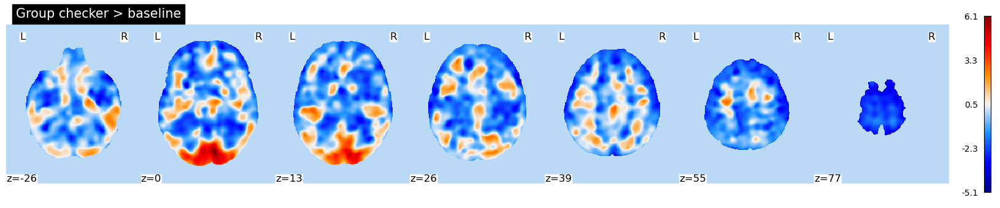

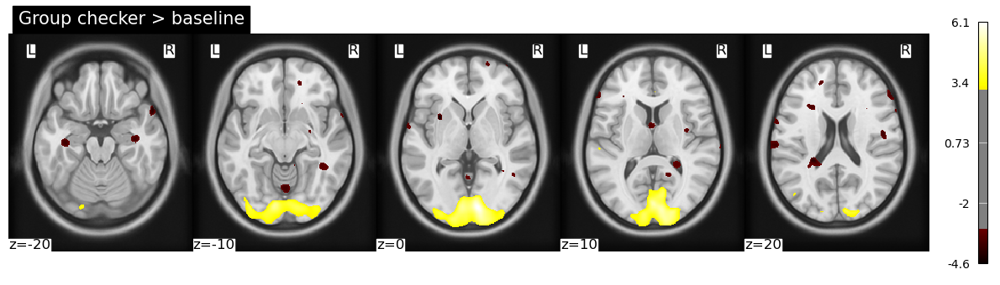

In [34]:
brainmask = os.path.join(script_path,
    "mni_MNI2009aNLinAsym_1mm_brmask.nii.gz")

! fslmaths {MNI_1mm_brain} -bin {brainmask}

cmrglcpath = Path(cmrglcpath)

maps_glm = [   str(
        cmrglcpath
        / f"sub-{subject:03d}"
        / "QUANT"
        / "GLM"
        / f"sub-fp{subject:03d}_quant-beta_reg-checker_space-MNI2009aNlinAsym.nii.gz")
    for subject in sids_cmrglc]

design_matrix = pd.DataFrame({"intercept": np.ones(len(maps_glm))})

second_level_glm = glm.second_level.SecondLevelModel(
    mask_img=brainmask,
    smoothing_fwhm=10).fit(
    maps_glm,
    design_matrix=design_matrix
)

stats_glm = second_level_glm.compute_contrast(
    second_level_contrast='intercept',
    output_type='all'
)

## plot non-corrected zstats
plotting.plot_img(stats_glm['z_score'], display_mode='z', bg_img=MNI_1mm, cmap=BlueRed,  
                 colorbar=True, title="Group checker > baseline")

##
thresholded_zmap, threshold_glm = glm.threshold_stats_img(
    stats_glm["z_score"],
    alpha=0.05,
    height_control="fdr",
    two_sided=True,   # use True if you also care about deactivations
    mask_img=brainmask
)


print("FDR z-threshold:", threshold_glm)

plotting.plot_img(thresholded_zmap, display_mode='z', bg_img=MNI_1mm, threshold=threshold_glm, cmap='hot', cut_coords=(-20, -10, 0, 10, 20), 
                colorbar=True, title="Group checker > baseline")


nib.save(thresholded_zmap, os.path.join(os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_2side_fdr_alpha05.nii.gz')))
GLM_PET_nii= os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_2side_fdr_alpha05.nii.gz')



/home/tumnic/sepp/.cache/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_from-MNI152NLin6Asym_mode-image_xfm.h5


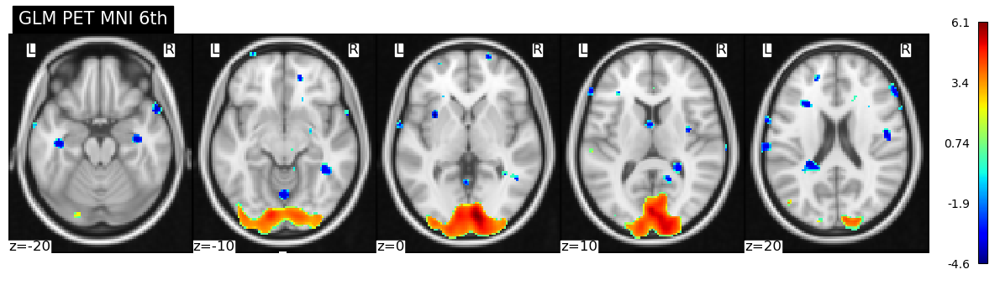

In [35]:
### problem: The GLM maps are in ICMB2009a NLin Asym template, the other maps in FSL MNI152 6th Nlin Asym; 
#we need to transform the second level results into this space before applying the GM group mask

##download matrix: from MNI6 to MNI152
from templateflow import api as tflow

xfm = tflow.get(
    "MNI152NLin2009cAsym",
    **{"from": "MNI152NLin6Asym"},
    mode="image",
    suffix="xfm",
    extension=".h5",
)

print(xfm)

## inverse matrix
GLM_PET_nii= os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_2side_fdr_alpha05.nii.gz')
GLM_PET_MNI6th_nii= os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_space-MNI6th_2ndlevel_2side_fdr_alpha05.nii.gz')
MNI_6th_2mm = os.path.join(script_path, 'MNI152_T1_2mm.nii.gz')

! antsApplyTransforms \
  -d 3 \
  -i {GLM_PET_nii} \
  -r {MNI_6th_2mm} \
  -o {GLM_PET_MNI6th_nii}\
  -t {xfm} \
  -n Linear

plotting.plot_img(GLM_PET_MNI6th_nii, display_mode='z', bg_img=MNI_6th_2mm, threshold=0, cmap='jet', cut_coords=(-20, -10, 0, 10, 20),
                colorbar=True, title="GLM PET MNI 6th")



### create nice 3D plot and axial slices

In [6]:
threshold_glm = 
## create mask ###
#########################
GLM_PET_MNI6th_nii= os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_space-MNI6th_2ndlevel_2side_fdr_alpha05.nii.gz')
GM_group_mask = os.path.join(derivatives_dir, 'task-loc_space-MNI152NLin6Asym_res-2_SNR_YEO_group_mask.nii.gz')
GLM_PET_GMmask = os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_GMmasked.nii.gz')
GLM_PET_mask = os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_mask.nii.gz')

! fslmaths {GLM_PET_MNI6th_nii} -mas {GM_group_mask} {GLM_PET_GMmask}
! fslmaths {GLM_PET_MNI6th_nii} -thr 0 -bin -mas {GM_group_mask} {GLM_PET_mask}

##Yeo's visual network
visual = os.path.join(derivatives_dir, 'Yeo2011_17Networks_MNI152_FreeSurferConformed2mm_MNI_visual.nii.gz')



##plot nicely
axial_save_name = results_dir + '/N' + str(len(sids)) + '_GLM_PET_2ndlevel_2side_fdr_alpha05_axial_noCBV.pdf'
    
plotting.plot_img(GLM_PET_GMmask, bg_img = MNI_2mm_brain,threshold = threshold_glm, display_mode='z', cmap=BlueRed, colorbar = True,
                        cut_coords = coords, vmax=7, vmin = -7,
                        output_file=axial_save_name)
plot = plotting.plot_img(GLM_PET_GMmask, bg_img = MNI_2mm_brain,threshold = threshold_glm, display_mode='z', cmap=BlueRed, colorbar = True,
                        cut_coords = (-20, -10, 0, 10, 20), vmax=7, vmin = -7)
plot.add_contours(visual,  colors='black', alpha = 1, linewidths=0.3)



NameError: name 'threshold_glm' is not defined

In [109]:

from matplotlib.colors import ListedColormap
newcmp_surface = ListedColormap(["lightgrey","darkorange", "darkorange", "darkorange"])

GLM_PET_mask = os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_mask.nii.gz')

maxval = 1

left_3D_name = results_dir + '/N' + str(len(sids)) + '_GLM_PET_2ndlevel_2side_fdr_alpha05_left_noCBV.pdf'
right_3D_name = results_dir + '/N' + str(len(sids)) + '_GLM_PET_2ndlevel_2side_fdr_alpha05_right_noCBV.pdf'

## 3D surface plot
texture_left = surface.vol_to_surf(GLM_PET_mask, fsaverage['pial_left'],  interpolation="nearest") 
texture_right = surface.vol_to_surf(GLM_PET_mask, fsaverage['pial_right'],interpolation="nearest")

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})

plot = plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4, vmax=maxval, threshold=0, 
                                cmap=newcmp_surface, axes=ax[0])

plot = plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1], 
                                output_file=left_3D_name)

plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='lateral', colorbar=False,
                               bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='lateral',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1],
                               output_file=right_3D_name)
plt.tight_layout() 

<Figure size 640x480 with 0 Axes>

### get MNI-space 2nd level mask into subject T2-space!

sub-fp001
sub-fp002
sub-fp003
sub-fp004
sub-fp007
sub-fp009
sub-fp010
sub-fp011
sub-fp013
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020


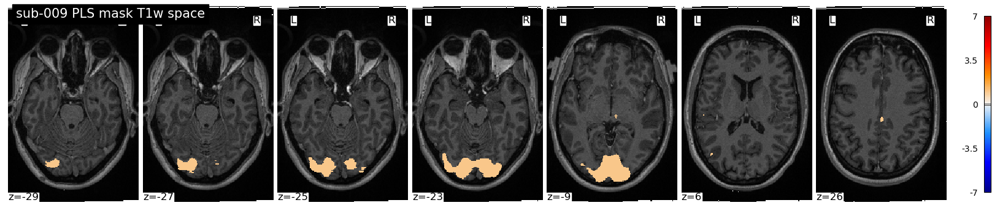

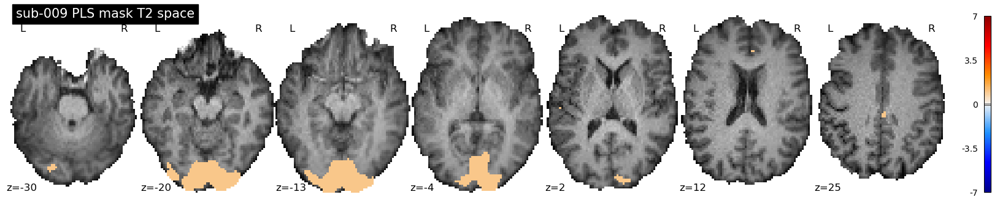

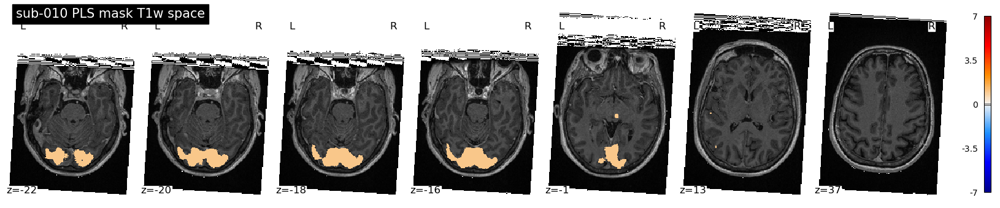

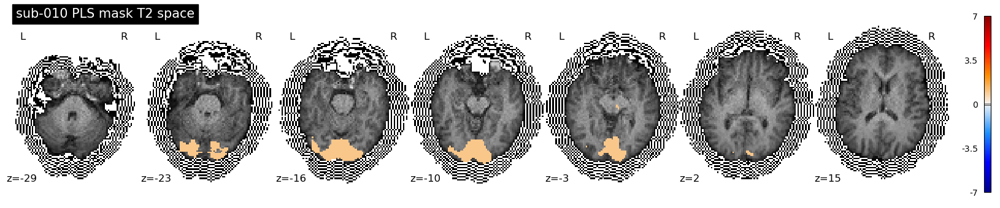

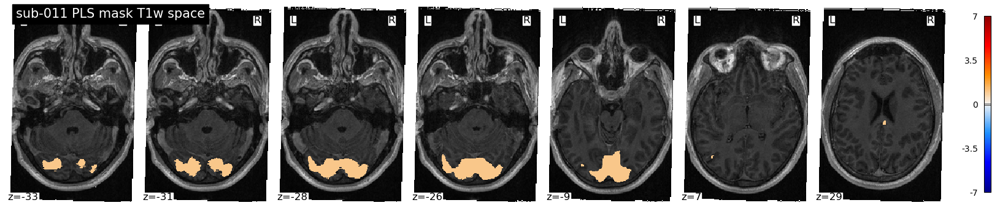

...

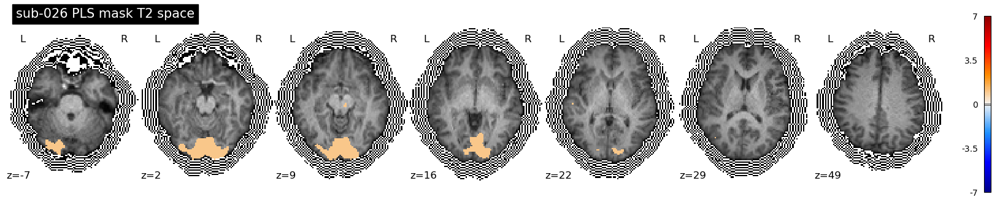

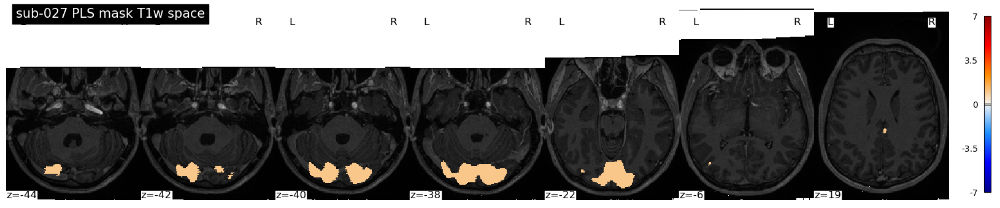

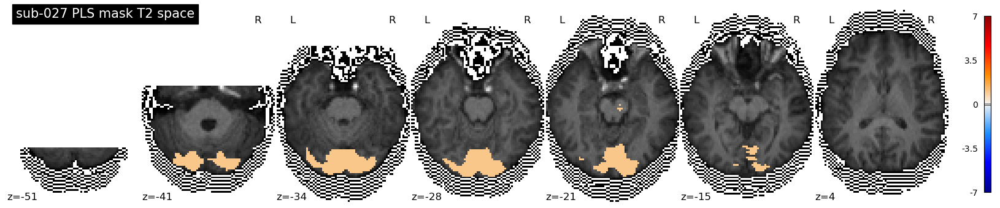

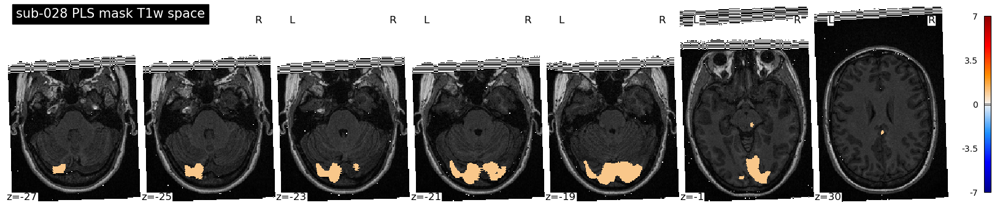

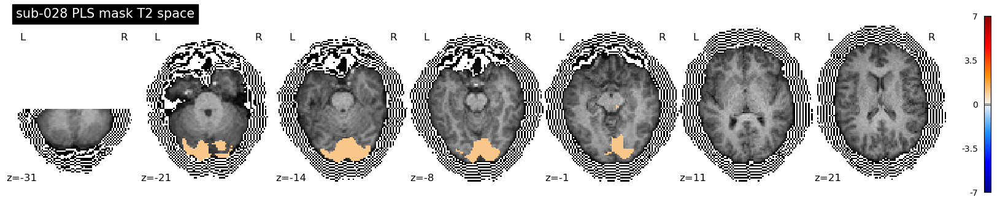

In [10]:
## take the MNI2009a space map (non-masked!) 

GLM_PET_nii= os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_2side_fdr_alpha05.nii.gz')
## only positive values, binarized
GLM_PET_nii_vismask= os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask.nii.gz')
! fslmaths {GLM_PET_nii} -thr {0} -bin {GLM_PET_nii_vismask}

for ID in sids_all:
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    subid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
    print(subid)
    sid="sub-{:03d}".format(ID+8) 

    subjfolder = os.path.join(data_dir, 'derivatives', sub)

    MNI_to_T1w = '/RAID1/jupytertmp/quantification/'+sid+'/transforms/mniicbm2anat.mat'
    
    ## output from fmriprep
    T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_deface.nii.gz')
    if not os.path.exists(T1w):
        T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w.nii.gz')

    br_mask=os.path.join(subjfolder, 'anat', sub + '_desc-brain_mask.nii.gz')



    ## apply transform: from MNI to T1w
    PETmask_T1space = os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T1w.nii.gz')
    ! flirt -in {GLM_PET_nii_vismask} -ref {T1w} -applyxfm -init  {MNI_to_T1w} -out {PETmask_T1space} -interp nearestneighbour

    ## plot results
    plot = plotting.plot_img(PETmask_T1space, bg_img = T1w,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sid + ' PLS mask T1w space')   

    
    ## get into T2 space
    T1w_brain=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_brain.nii.gz')
    T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   
    T1w_T2space_brain=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w_brain.nii.gz')
    T1_to_T2 =os.path.join(subjfolder, 'anat', sub + '_from_T1w_2_T2space.nii.gz')
    PETmask_T2space = os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')
    ! flirt -in {T1w_brain} -ref {T1w_T2space_brain} -omat {T1_to_T2} -dof 6 -interp nearestneighbour
    
    ! flirt -in {PETmask_T1space} -ref {T1w_T2space} -applyxfm -init  {T1_to_T2} -out {PETmask_T2space} -interp nearestneighbour
    ## plot results
    plot = plotting.plot_img(PETmask_T2space, bg_img = T1w_T2space_brain,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sid + ' PLS mask T2 space')

#### apply qBOLD masking

In [11]:
## run qBOLD toolbox
%run qBOLD_fun.ipynb

#grey matter mask
GMthresh = 0.5; #mandatory

#mask CSF influenced areas
T2thresh = 150; #mandatory

#mask R2strich artifact areas
R2thresh = 11 ; #mandatory

#mask CBV 
CBVthresh = 12; #optional: comment out if not used, default = 20

#mask T2S
T2Sthresh = 90; #optional: comment out if not used, default = 150

#mask OEF
OEFthresh = 1; #optional: comment out if not used, default = 1

#mask CBF
CBFthresh = 120; #optional: comment out if not used, default = 150

Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply 

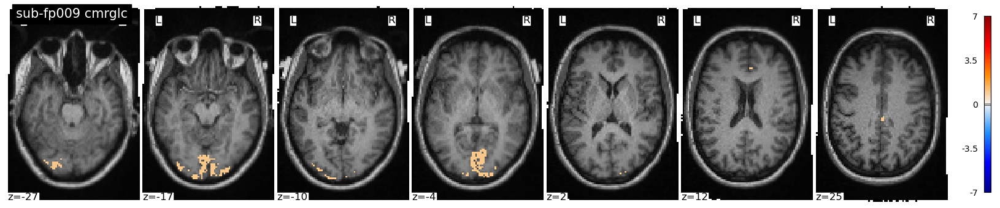

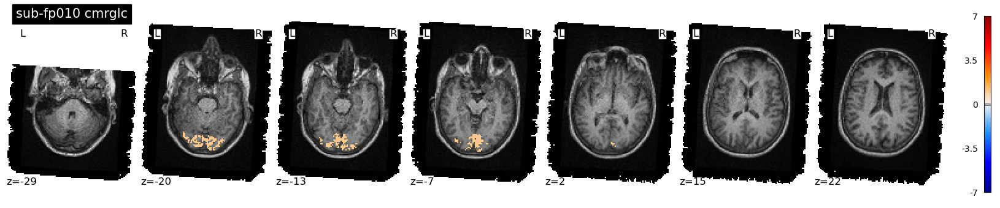

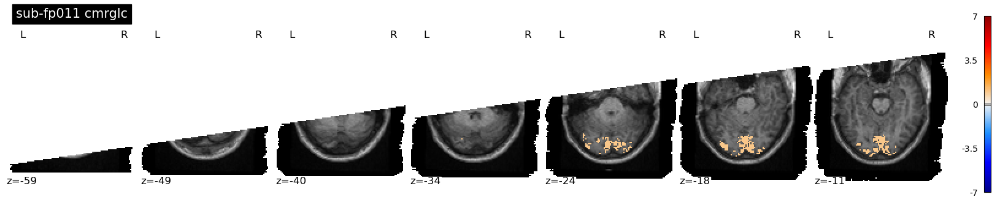

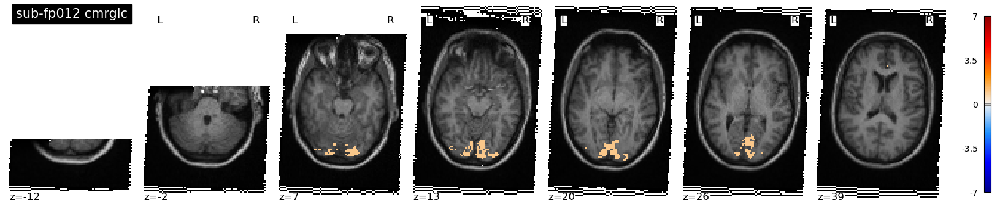

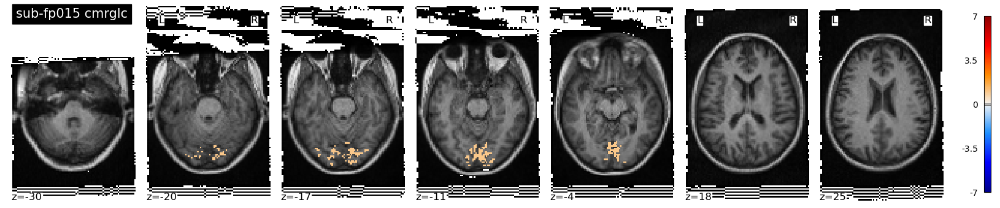

...

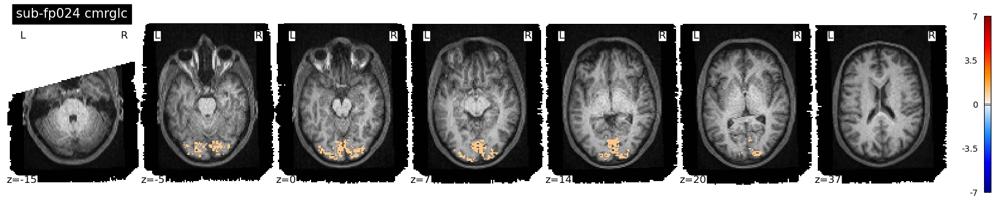

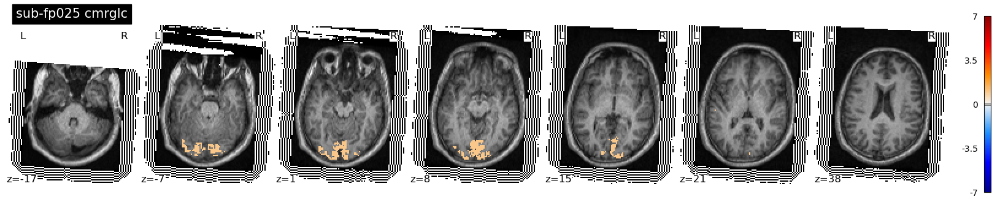

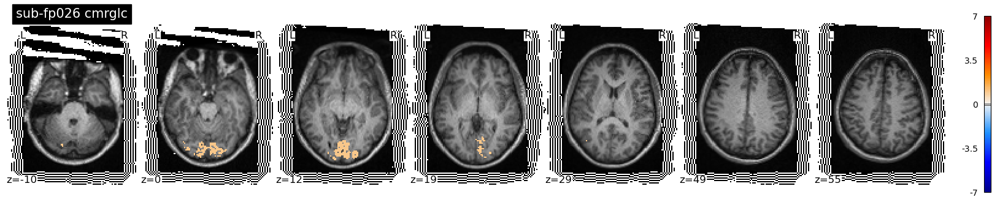

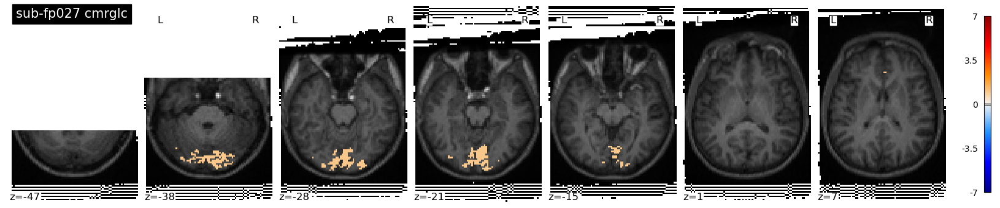

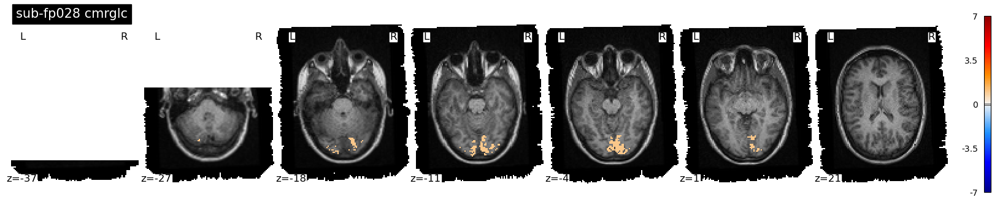

In [13]:
## cmrglc
parameters=['cmrglc']

#joint_sids = list(dict.fromkeys(sids + sids_cmrglc))
#sids_cmrglc=[4, 5]
for p, par in enumerate(parameters):
    for i, ID in enumerate(sids_all): #loop over subjects
        sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
        subjfolder = os.path.join(data_dir, 'derivatives', sub)
        T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   
        
        mask_list = create_qBOLD_masks(sub, subjfolder, conds, GMthresh, T2thresh, R2thresh, CBVthresh, T2Sthresh, OEFthresh,  CBFthresh=None)                
        PETmask_T2space = os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')

        ##mask parameter map
        out_name = PETmask_T2space[:-7] + '_qBmasked.nii.gz'
        par_masked = mask_nii(PETmask_T2space, mask_list, out_name)
            
        plotting.plot_img(par_masked, bg_img = T1w_T2space, threshold=0.1, vmin=-7, vmax=7, display_mode='z', cmap=BlueRed, colorbar=True, title = sub + ' ' + par)

## 2. BOLD: do the same as above with nilearn on the 1st level images

#### run the GLM

FDR z-threshold: 3.0967319714760753


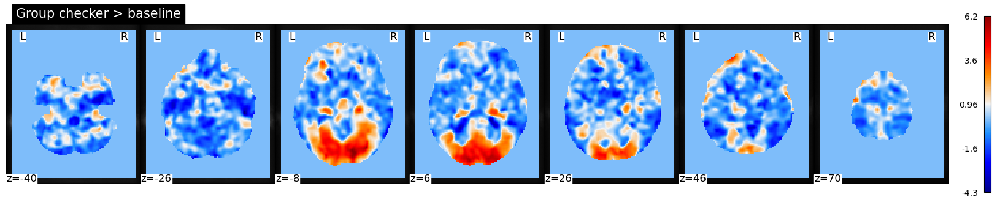

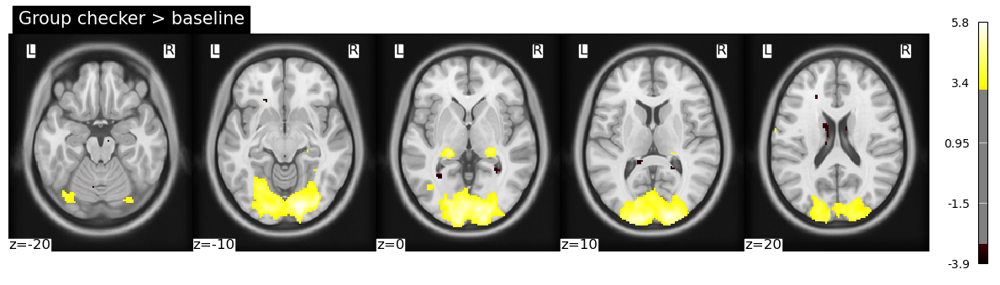

In [18]:
from pathlib import Path
import subprocess


brainmask = os.path.join(script_path, 'MNI152_T1_2mm_brmsk.nii.gz')

derivatives_path = Path(derivatives_dir)


maps_glm = [   str(
        derivatives_path
        / f"sub-fp{subject+8:03d}"
        / "func"
        / f"sub-fp{subject+8:03d}_space-MNI152NLin6Asym_cope1.nii.gz")
    for (subject) in sids]

design_matrix = pd.DataFrame({"intercept": np.ones(len(maps_glm))})

second_level_glm = glm.second_level.SecondLevelModel(
    mask_img=brainmask,
    smoothing_fwhm=5).fit(
    maps_glm,
    design_matrix=design_matrix
)


stats_glm = second_level_glm.compute_contrast(
    second_level_contrast='intercept',
    output_type='all'
)

## plot non-corrected zstats
plotting.plot_img(stats_glm['z_score'], display_mode='z', bg_img=MNI_1mm, cmap=BlueRed,  
                 colorbar=True, title="Group checker > baseline")

##
thresholded_zmap, threshold_glm = glm.threshold_stats_img(
    stats_glm["z_score"],
    alpha=0.05,
    height_control="fdr",
    two_sided=True,   # use True if you also care about deactivations
    mask_img=brainmask
)


print("FDR z-threshold:", threshold_glm)

plotting.plot_img(thresholded_zmap, display_mode='z', bg_img=MNI_1mm, threshold=threshold_glm, cmap='hot', cut_coords=(-20, -10, 0, 10, 20),
                colorbar=True, title="Group checker > baseline")
nib.save(thresholded_zmap, os.path.join(os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_GLM_BOLD_2ndlevel_2side_fdr_alpha05.nii.gz')))


### create nice brainplot + 3D mask

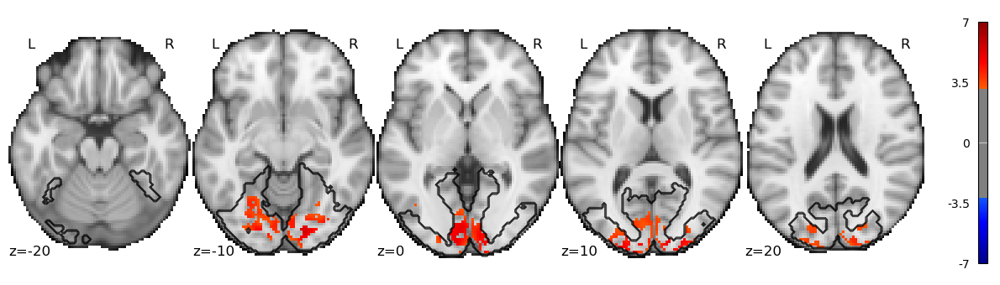

In [42]:

##Yeo's visual network
visual = os.path.join(derivatives_dir, 'Yeo2011_17Networks_MNI152_FreeSurferConformed2mm_MNI_visual.nii.gz')

## create mask ###
#########################
GLM_BOLD_nii= os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_GLM_BOLD_2ndlevel_2side_fdr_alpha05.nii.gz')
GM_group_mask = os.path.join(derivatives_dir, 'task-loc_space-MNI152NLin6Asym_res-2_SNR_YEO_group_mask.nii.gz')
GLM_BOLD_mask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_GLM_BOLD_2ndlevel_mask.nii.gz')
GLM_BOLD_GMmask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_GLM_BOLD_2ndlevel_GMmasked.nii.gz')

! fslmaths {GLM_BOLD_nii} -mas {GM_group_mask} {GLM_BOLD_GMmask}
! fslmaths {GLM_BOLD_nii} -thr 0 -bin -mas {GM_group_mask} {GLM_BOLD_mask}

#plotting.plot_img(GLM_BOLD_GMmask, display_mode='z', bg_img=MNI_2mm, threshold=0, cmap='jet', cut_coords=(-20, -10, 0, 10, 20),
#                colorbar=True, title="masked activity")

##plot nicely
axial_save_name = results_dir + '/N' + str(len(sids)) + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_axial_noCBV.pdf'
    
plotting.plot_img(GLM_BOLD_GMmask, bg_img = MNI_2mm_brain,threshold = threshold_glm, display_mode='z', cmap=BlueRed, colorbar = True,
                        cut_coords = coords, vmax=7, vmin = -7,
                        output_file=axial_save_name)
plot = plotting.plot_img(GLM_BOLD_GMmask, bg_img = MNI_2mm_brain,threshold = threshold_glm, display_mode='z', cmap=BlueRed, colorbar = True,
                        cut_coords = (-20, -10, 0, 10, 20), vmax=7, vmin = -7)
plot.add_contours(visual,  colors='black', alpha = 1, linewidths=0.3)



In [118]:

from matplotlib.colors import ListedColormap
newcmp_surface = ListedColormap(["lightgrey","darkorange", "darkorange", "darkorange"])

GLM_BOLD_mask = os.path.join(derivatives_dir, 'N'+str(len(sids_cmrglc))+ '_GLM_BOLD_2ndlevel_mask.nii.gz')

maxval = 1

left_3D_name = results_dir + '/N' + str(len(sids)) + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_left_noCBV.pdf'
right_3D_name = results_dir + '/N' + str(len(sids)) + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_right_noCBV.pdf'

## 3D surface plot
texture_left = surface.vol_to_surf(GLM_BOLD_mask, fsaverage['pial_left'],  interpolation="nearest") 
texture_right = surface.vol_to_surf(GLM_BOLD_mask, fsaverage['pial_right'],interpolation="nearest")

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})

plot = plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4, vmax=maxval, threshold=0, 
                                cmap=newcmp_surface, axes=ax[0])

plot = plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1], 
                                output_file=left_3D_name)

plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='lateral', colorbar=False,
                               bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='lateral',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1],
                               output_file=right_3D_name)
plt.tight_layout() 

<Figure size 640x480 with 0 Axes>

### get 2nd level into subject-level T2 space

In [ ]:
## take the MNI2009a space map (non-masked!) 
GLM_BOLD_nii= os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_GLM_BOLD_2ndlevel_2side_fdr_alpha05.nii.gz')
## only positive values, binarized
GLM_BOLD_nii_vismask= os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask.nii.gz')
! fslmaths {GLM_BOLD_nii} -thr {0} -bin {GLM_BOLD_nii_vismask}

for ID in sids:
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    subid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
    print(subid)
    sid="sub-{:03d}".format(ID+8) 

    subjfolder = os.path.join(data_dir, 'derivatives', sub)

    
    ## output from fmriprep
    T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_deface.nii.gz')
    if not os.path.exists(T1w):
        T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w.nii.gz')

    br_mask=os.path.join(subjfolder, 'anat', sub + '_desc-brain_mask.nii.gz')

    ## from fmriprep: 
    MNI_to_T1w = os.path.join(subjfolder, 'anat', sub + '_from-MNI152NLin6Asym_to-T1w_mode-image_xfm.h5')

    ## apply transform: from MNI to T1w
    BOLDmask_T1space = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T1w.nii.gz')
    ! antsApplyTransforms -d 3 --float 1 --verbose 1 -i {GLM_BOLD_nii_vismask} -r {T1w} -t {MNI_to_T1w} -o {BOLDmask_T1space}
    

    ## plot results
    plot = plotting.plot_img(BOLDmask_T1space, bg_img = T1w,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sid + ' BOLD mask T1w space')   

    
    ## get into T2 space
    T1w_brain=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_brain.nii.gz')
    T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   
    T1w_T2space_brain=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w_brain.nii.gz')
    T1_to_T2 =os.path.join(subjfolder, 'anat', sub + '_from_T1w_2_T2space.mat')
    BOLDmask_T2space = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')
    ! flirt -in {T1w_brain} -ref {T1w_T2space_brain} -omat {T1_to_T2} -dof 6 -interp nearestneighbour
    
    ! flirt -in {BOLDmask_T1space} -ref {T1w_T2space} -applyxfm -init  {T1_to_T2} -out {BOLDmask_T2space} -interp nearestneighbour
    ## plot results
    plot = plotting.plot_img(BOLDmask_T2space, bg_img = T1w_T2space_brain,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sid + 'BOLD mask T2 space')

### apply qBOLD masking

In [20]:
## run qBOLD toolbox
%run qBOLD_fun.ipynb

#grey matter mask
GMthresh = 0.5; #mandatory

#mask CSF influenced areas
T2thresh = 150; #mandatory

#mask R2strich artifact areas
R2thresh = 11 ; #mandatory

#mask CBV 
CBVthresh = 12; #optional: comment out if not used, default = 20

#mask T2S
T2Sthresh = 90; #optional: comment out if not used, default = 150

#mask OEF
OEFthresh = 1; #optional: comment out if not used, default = 1

#mask CBF
CBFthresh = 120; #optional: comment out if not used, default = 150

sub-fp001
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp002
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp004
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp007
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp010
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp011
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp014
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp015
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp016
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp017
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp018
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply ma

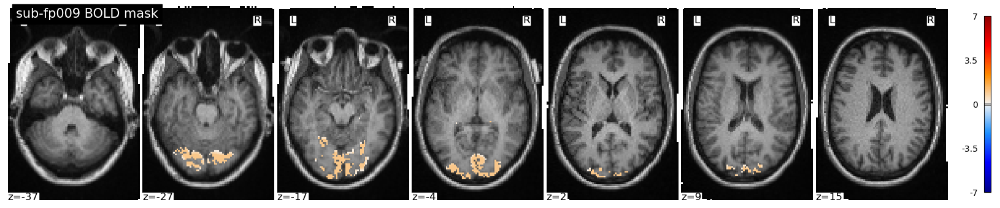

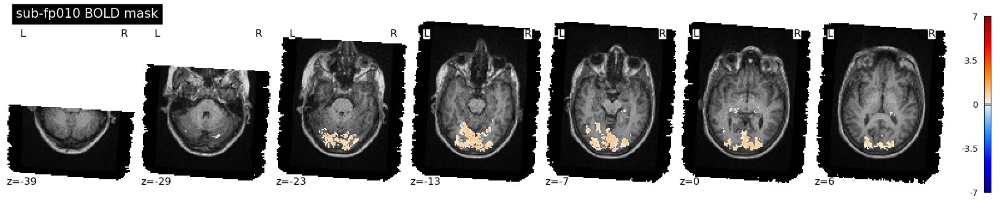

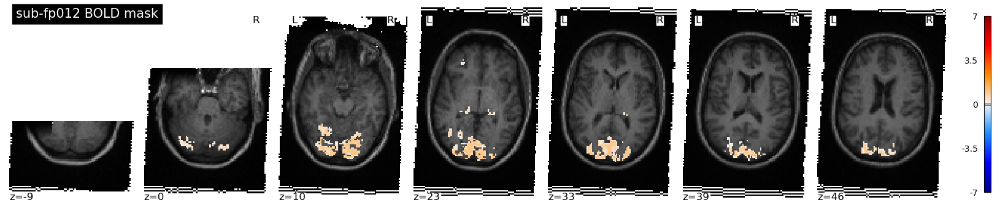

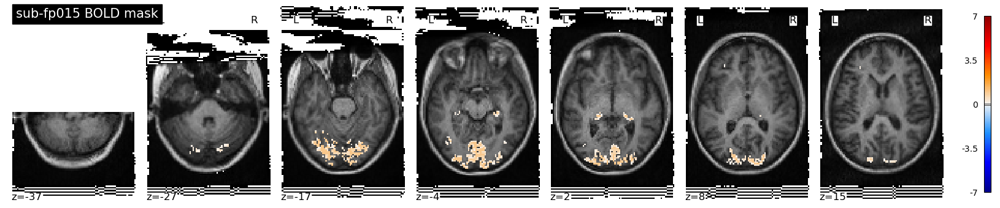

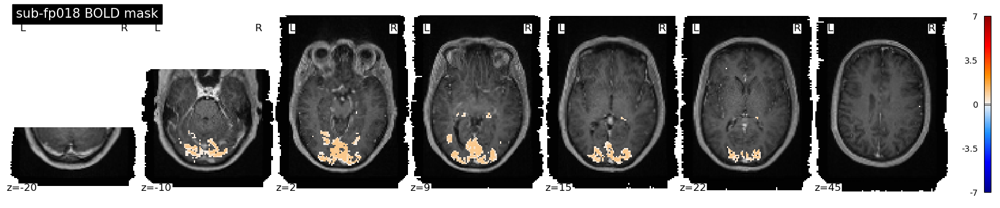

...

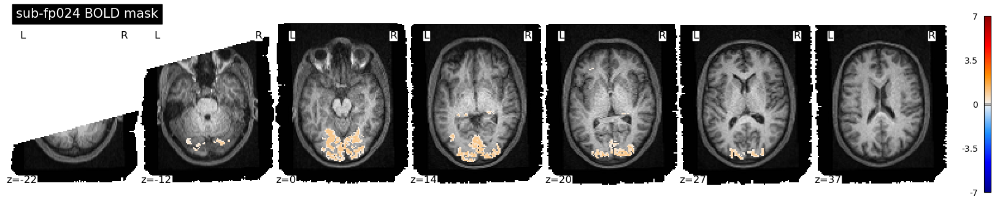

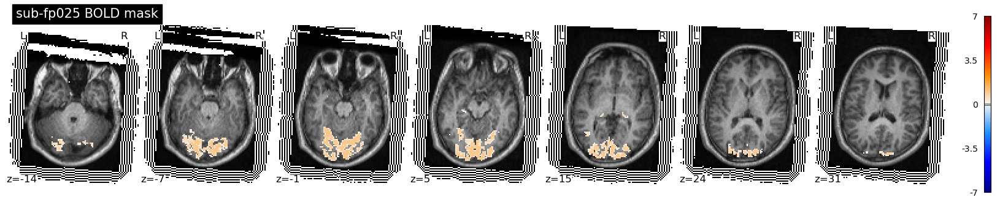

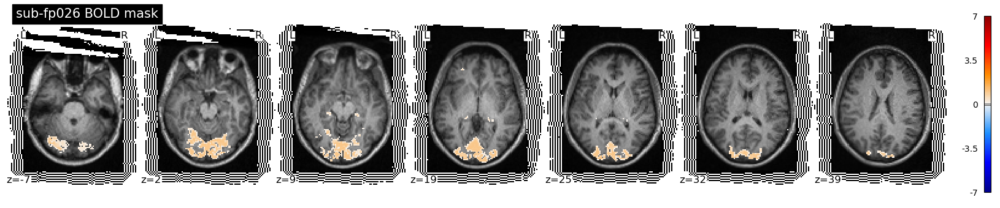

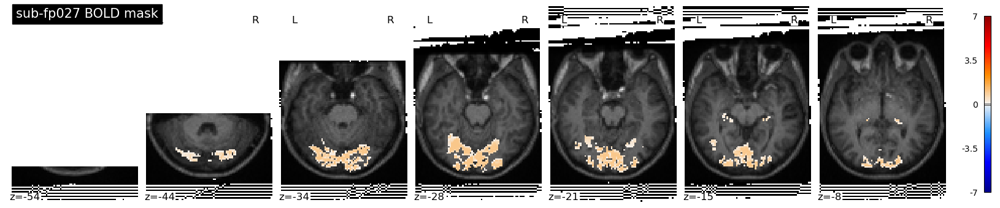

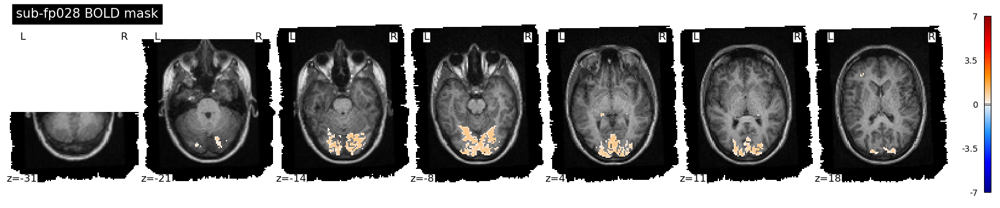

In [21]:
## mask the native-space visual activation 
for i, ID in enumerate(sids): #loop over subjects
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
    print(sid)
    subjfolder = os.path.join(data_dir, 'derivatives', sub)
    T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   
    
    mask_list = create_qBOLD_masks(sub, subjfolder, conds, GMthresh, T2thresh, R2thresh, CBVthresh, T2Sthresh, OEFthresh,  CBFthresh=None)                
    BOLDmask_T2space = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')

    ##mask parameter map
    out_name = BOLDmask_T2space[:-7] + '_qBmasked.nii.gz'
    par_masked = mask_nii(BOLDmask_T2space, mask_list, out_name)
        
    plotting.plot_img(par_masked, bg_img = T1w_T2space, threshold=0.1, vmin=-7, vmax=7, display_mode='z', cmap=BlueRed, colorbar=True, title = sub + ' BOLD mask')


# 3. Run PLS 

### a. Input

In [22]:

## load MNI and apply mask to get right shape for PLS input
masker = input_data.NiftiMasker(mask_img=GM_SNR_mask)
MNI_arr = masker.fit_transform(MNI_2mm_brain)

#pre-define PLS input: all voxels vor every subject per condition
PLS_input_CBF=np.empty([len(sids)*len(conds), MNI_arr.shape[1]])
PLS_input_OEF=np.empty([len(sids)*len(conds), MNI_arr.shape[1]])
PLS_input_CMRO2=np.empty([len(sids)*len(conds), MNI_arr.shape[1]])

for i, ID in enumerate(sids): #loop over subjects
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
    print(sid)

    sub_dir = os.path.join(data_dir, sub)

    dir_deriv = os.path.join(derivatives_dir, sub)
                
    for k, cond in enumerate(conds): 

        ## CBF
        
        CBF_normalized = os.path.join(dir_deriv, 'qmri', sub+'_task-' + cond + '_space-MNI152_cbf.nii.gz')
                                        
        ## apply GM mask (with GM_thr defined)
        masker = input_data.NiftiMasker(mask_img=GM_SNR_mask)
        CBF_arr = masker.fit_transform(CBF_normalized)

        PLS_input_CBF[k*len(sids)+i,:]=CBF_arr;

        ## OEF

        if cond == 'open':
            OEF_normalized = os.path.join(dir_deriv, 'qmri', sub+'_task-' + cond +'_space-MNI152_oef.nii.gz')
        if cond == 'checker':
            OEF_normalized = os.path.join(dir_deriv, 'qmri', sub+'_task-' + cond +'_space-MNI152_desc-30perc_oef.nii.gz')

        ## apply GM mask (with GM_thr defined)
        masker = input_data.NiftiMasker(mask_img=GM_SNR_mask)
        OEF_arr = masker.fit_transform(OEF_normalized)
        PLS_input_OEF[k*len(sids)+i,:]=OEF_arr;
        
        ## CMRO2
        
        if cond == 'open':
            CMRO2_normalized = os.path.join(dir_deriv, 'qmri', sub+'_task-' + cond + '_space-MNI152_cmro2.nii.gz')
        if cond == 'checker':
            CMRO2_normalized = os.path.join(dir_deriv, 'qmri', sub+'_task-' + cond + '_space-MNI152_desc-30perc_cmro2.nii.gz')

        ## apply GM mask (with GM_thr defined)
        masker = input_data.NiftiMasker(mask_img=GM_SNR_mask)
        CMRO2_arr = masker.fit_transform(CMRO2_normalized)
        PLS_input_CMRO2[k*len(sids)+i,:]=CMRO2_arr;

##save data structure
if CBV_masking == 'no':
    np.save(results_dir + '/N'+str(len(sids)) + 'PLS_OEF_open_checker_30perc_input_noCBVmask.npy', PLS_input_OEF)
    np.save(results_dir + '/N'+str(len(sids)) + 'PLS_CBF_open_checker_input_noCBVmask.npy', PLS_input_CBF)
    np.save(results_dir + '/N'+str(len(sids)) + 'PLS_CMRO2_open_checker_30perc_input_noCBVmask.npy', PLS_input_CMRO2)
if CBV_masking == 'yes':
    np.save(results_dir + '/N'+str(len(sids)) + 'PLS_OEF_open_checker_30perc_input.npy', PLS_input_OEF)
    np.save(results_dir + '/N'+str(len(sids)) + 'PLS_CBF_open_checker_input.npy', PLS_input_CBF)
    #np.save(results_dir + '/N'+str(len(sids)) + 'PLS_CMRO2_open_checker_30perc_input.npy', PLS_input_CMRO2)
    #np.save(results_dir + '/N'+str(len(sids)) + 'PLS_CMRO2_open_checker_0perc_input.npy', PLS_input_CMRO2)

sub-fp001
sub-fp002
sub-fp004
sub-fp007
sub-fp010
sub-fp011
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020


### b. run PLS

In [18]:
## CBF
if CBV_masking == 'yes':
    PLS_input_CBF_median= np.load(results_dir + '/N'+str(len(sids)) + 'PLS_CBF_open_checker_input.npy')
    mpls_CBF_open_checker = pyls.meancentered_pls(PLS_input_CBF_median, n_cond=len(conds), n_perm=2000, n_boot=2000)
    np.save(results_dir + '/N'+str(len(sids))  + '_PLSresult_CBF_visstim.npy', mpls_CBF_open_checker)
if CBV_masking == 'no':
    PLS_input_CBF_median= np.load(results_dir + '/N'+str(len(sids)) + 'PLS_CBF_open_checker_input_noCBVmask.npy')
    mpls_CBF_open_checker = pyls.meancentered_pls(PLS_input_CBF_median, n_cond=len(conds), n_perm=2000, n_boot=2000)
    np.save(results_dir + '/N'+str(len(sids))  + '_PLSresult_CBF_visstim_noCBVmask.npy', mpls_CBF_open_checker)
## OEF
if CBV_masking == 'yes':
    PLS_input_OEF_median= np.load(results_dir + '/N'+str(len(sids)) + 'PLS_OEF_open_checker_30perc_input.npy')
    mpls_OEF_open_checker = pyls.meancentered_pls(PLS_input_OEF_median, n_cond=len(conds), n_perm=2000, n_boot=2000)
    np.save(results_dir + '/N'+str(len(sids))  + '_PLSresult_OEF_visstim.npy', mpls_OEF_open_checker)
if CBV_masking == 'no':
    PLS_input_OEF_median= np.load(results_dir + '/N'+str(len(sids)) + 'PLS_OEF_open_checker_30perc_input_noCBVmask.npy')
    mpls_OEF_open_checker = pyls.meancentered_pls(PLS_input_OEF_median, n_cond=len(conds), n_perm=2000, n_boot=2000)
    np.save(results_dir + '/N'+str(len(sids))  + '_PLSresult_OEF_visstim_noCBVmask.npy', mpls_OEF_open_checker)
## CMRO2
if CBV_masking == 'yes':
    PLS_input_CMRO2_median= np.load(results_dir + '/N'+str(len(sids)) + 'PLS_CMRO2_open_checker_30perc_input.npy')
    mpls_CMRO2_open_checker = pyls.meancentered_pls(PLS_input_CMRO2_median, n_cond=len(conds), n_perm=2000, n_boot=2000)
    np.save(results_dir + '/N'+str(len(sids))  + '_PLSresult_CMRO2_visstim.npy', mpls_CMRO2_open_checker)
if CBV_masking == 'no':
    PLS_input_CMRO2_median= np.load(results_dir + '/N'+str(len(sids)) + 'PLS_CMRO2_open_checker_30perc_input_noCBVmask.npy')
    mpls_CMRO2_open_checker = pyls.meancentered_pls(PLS_input_CMRO2_median, n_cond=len(conds), n_perm=2000, n_boot=2000)
    np.save(results_dir + '/N'+str(len(sids))  + '_PLSresult_CMRO2_visstim_noCBVmask.npy', mpls_CMRO2_open_checker)

In [25]:
## load results
if CBV_masking == 'yes':
    mpls_CBF_visstim = np.load(results_dir + '/N'+str(len(sids))  + '_PLSresult_CBF_visstim.npy', allow_pickle='TRUE').item()
    mpls_OEF_visstim = np.load(results_dir + '/N'+str(len(sids))  + '_PLSresult_OEF_visstim.npy', allow_pickle='TRUE').item()
    mpls_CMRO2_visstim = np.load(results_dir + '/N'+str(len(sids))  + '_PLSresult_CMRO2_visstim.npy', allow_pickle='TRUE').item()
if CBV_masking == 'no':
    mpls_CBF_visstim = np.load(results_dir + '/N'+str(len(sids))  + '_PLSresult_CBF_visstim_noCBVmask.npy', allow_pickle='TRUE').item()
    mpls_OEF_visstim = np.load(results_dir + '/N'+str(len(sids))  + '_PLSresult_OEF_visstim_noCBVmask.npy', allow_pickle='TRUE').item()
    mpls_CMRO2_visstim = np.load(results_dir + '/N'+str(len(sids))  + '_PLSresult_CMRO2_visstim_noCBVmask.npy', allow_pickle='TRUE').item()

### Results of PLS

[0.0009995  0.77311344]
[0.50724638 0.97401299]
[4.99750125e-04 8.70064968e-01]
                   1
conditions          
open        0.707107
checker    -0.707107


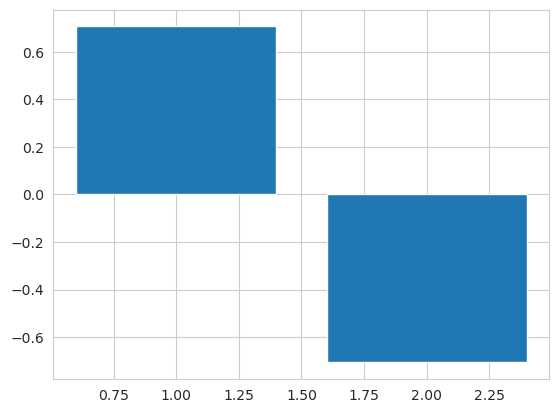

                   1
conditions          
open       -0.707107
checker     0.707107


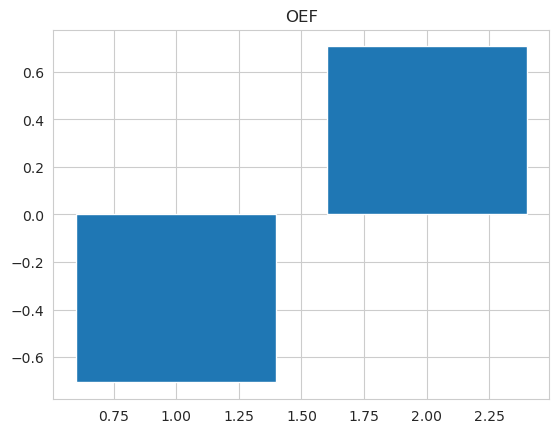

                   1
conditions          
open        0.707107
checker    -0.707107


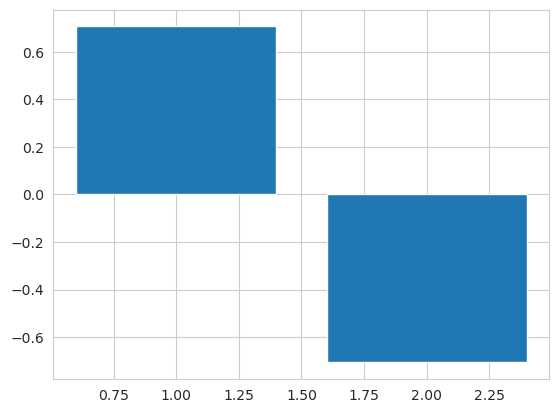

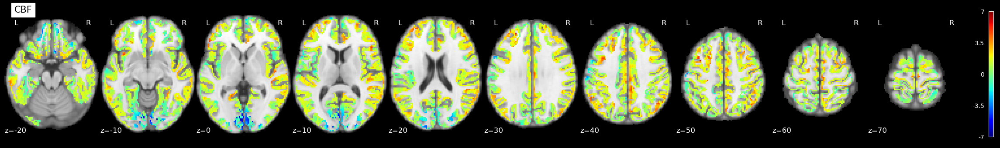

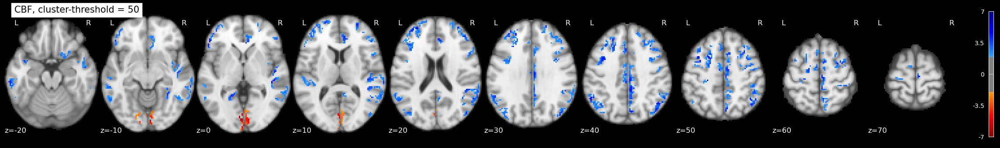

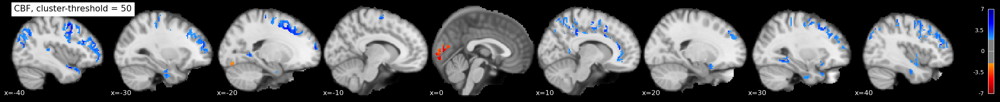

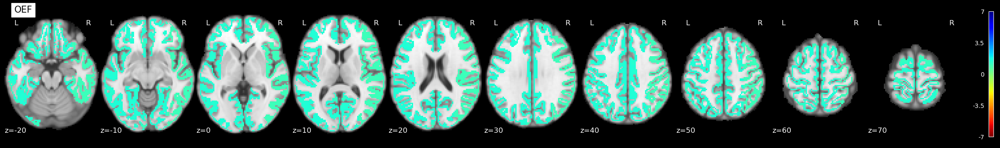

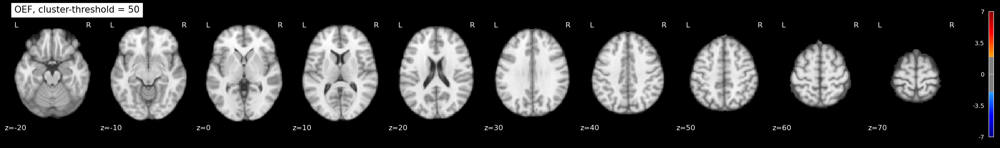

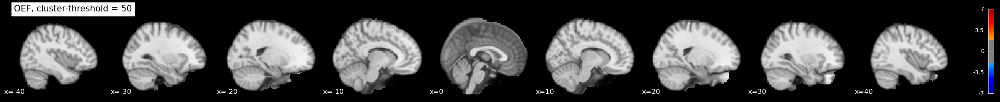

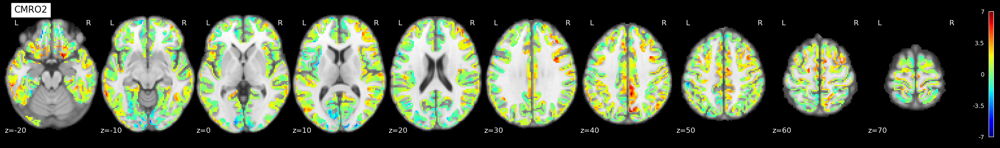

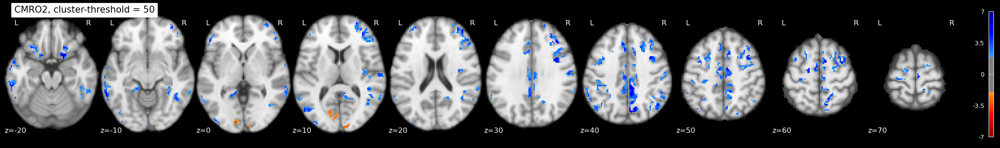

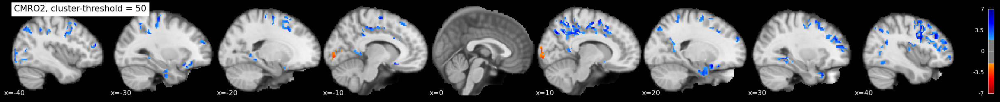

In [26]:
#####################################################################
## p-values ############################################
######################################################################

print(mpls_CBF_visstim.permres.pvals)
print(mpls_OEF_visstim.permres.pvals)
print(mpls_CMRO2_visstim.permres.pvals)

#####################################################################
### design scores ############################################
######################################################################

## CBF ##
##########
design_scores_CBF = [mpls_CBF_visstim.y_scores[i, 0] for i in range(0,len(mpls_CBF_visstim.y_scores))]## first latent variables (significant)
design_scores_df_CBF = pd.DataFrame(columns = [1], index=conds) 
design_scores_df_CBF.index.name = 'conditions'


## 2 conditions
design_scores_df_CBF.loc['open'] = design_scores_CBF[len(sids)-1]
design_scores_df_CBF.loc['checker'] = design_scores_CBF[2*len(sids)-1]
print(design_scores_df_CBF)

##plot
plt.bar([1, 2],[design_scores_df_CBF.loc['open'][1], design_scores_df_CBF.loc['checker'][1]])
plt.show()

## OEF ##
 ##########
design_scores_OEF = [mpls_OEF_visstim.y_scores[i, 0] for i in range(0,len(mpls_OEF_visstim.y_scores))]## first latent variables (significant)
design_scores_df_OEF = pd.DataFrame(columns = [1], index=conds) 
design_scores_df_OEF.index.name = 'conditions'


## 2 conditions
design_scores_df_OEF.loc['open'] = design_scores_OEF[len(sids)-1]
design_scores_df_OEF.loc['checker'] = design_scores_OEF[2*len(sids)-1]
print(design_scores_df_OEF)

 ##plot
plt.bar([1, 2],[design_scores_df_OEF.loc['open'][1], design_scores_df_OEF.loc['checker'][1]])
plt.title('OEF')
plt.show()


## CMRO2 ##
##########

design_scores_CMRO2 = [mpls_CMRO2_visstim.y_scores[i, 0] for i in range(0,len(mpls_CMRO2_visstim.y_scores))]## first latent variables (significant)
design_scores_df_CMRO2 = pd.DataFrame(columns = [1], index=conds) 
design_scores_df_CMRO2.index.name = 'conditions'


## 2 conditions
design_scores_df_CMRO2.loc['open'] = design_scores_CMRO2[len(sids)-1]
design_scores_df_CMRO2.loc['checker'] = design_scores_CMRO2[2*len(sids)-1]
print(design_scores_df_CMRO2)

##plot
plt.bar([1, 2],[design_scores_df_CMRO2.loc['open'][1], design_scores_df_CMRO2.loc['checker'][1]])
plt.show()

#####################################################################
### bootstrap ratios ############################################
######################################################################
coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70)
BSR_thr=2
#BSR_thr = 2.58
maxval_axial = 7
maxval = 6
thr = 0
colormap=BlueRed
colormap_r=BlueRed_r

## CBF ##
########

bootstrap_results_CBF = [mpls_CBF_visstim.bootres.x_weights_normed[i, 0] for i in range(0, len(mpls_CBF_visstim.bootres.x_weights_normed))] # for first latent variable
bootstrap_results_2ndLV_CBF = [mpls_CBF_visstim.bootres.x_weights_normed[i, 1] for i in range(0, len(mpls_CBF_visstim.bootres.x_weights_normed))] # for first latent variable

##plot
masker = input_data.NiftiMasker(mask_img=GM_SNR_mask)
MNI_arr = masker.fit_transform(MNI_2mm_brain)
BSR_masked_CBF = masker.inverse_transform(bootstrap_results_CBF)
BSR_masked_CBF_2ndLV = masker.inverse_transform(bootstrap_results_2ndLV_CBF)

plotting.plot_img(BSR_masked_CBF, bg_img=MNI_2mm_brain, threshold = 0, display_mode='z', cmap='jet', colorbar = True, black_bg=True,
                cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), title='CBF', vmin = -7, vmax=7)
#plotting.plot_img(BSR_masked_CBF, bg_img=MNI, threshold = 2, display_mode='z', cmap='jet', colorbar = True, black_bg=True,
#                cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), title='CBF', vmin = -7, vmax=7)

## apply cluster threshold
BSR_cluster_thr = glm.threshold_stats_img(BSR_masked_CBF, mask_img=None, alpha=0.05, threshold=BSR_thr, height_control=None, cluster_threshold=50, two_sided=True)

if CBV_masking == 'yes':
    nib.save(BSR_cluster_thr[0], os.path.join( results_dir, 'N' + str(len(sids))  + '_meanPLS_CBF_LV1_BSR_clust_z' + str(BSR_thr)+ '.nii.gz'))
if CBV_masking == 'no':
    nib.save(BSR_cluster_thr[0], os.path.join( results_dir, 'N' + str(len(sids))  + '_meanPLS_CBF_LV1_BSR_clust_z' + str(BSR_thr)+ '_noCBVmask.nii.gz'))
    
if design_scores_df_CBF.loc['checker'][1] > 0: #higher in calc
    my_color = colormap
if design_scores_df_CBF.loc['checker'][1] < 0: #higher in calc
    my_color = colormap_r
    
plotting.plot_img(BSR_cluster_thr[0], bg_img=MNI_2mm_brain, threshold = BSR_thr, display_mode='z', cmap=my_color, colorbar = True, black_bg=True,
                cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), vmin = -7, vmax=7, title='CBF, cluster-threshold = 50')
plotting.plot_img(BSR_cluster_thr[0], bg_img=MNI_2mm_brain, threshold = BSR_thr, display_mode='x', cmap=my_color, colorbar = True, black_bg=True,
                 cut_coords = (-40, -30, -20, -10, 0, 10, 20, 30, 40),vmin = -7, vmax=7, title='CBF, cluster-threshold = 50')
nib.save(BSR_cluster_thr[0], results_dir + '/N' + str(len(sids))  + '_meanPLS_CBF_LV1_BSR_clust_z' + str(BSR_thr)+ '.nii.gz')

##2nd LV
#plotting.plot_img(BSR_masked_CBF_2ndLV, bg_img=MNI_2mm_brain, threshold = 0.5, display_mode='z', cmap=my_color, colorbar = True, black_bg=True,
#                cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), vmin = -7, vmax=7, title='CBF')


## OEF ##
########

bootstrap_results_OEF = [mpls_OEF_visstim.bootres.x_weights_normed[i, 0] for i in range(0, len(mpls_OEF_visstim.bootres.x_weights_normed))] # for first latent variable

##plot
masker = input_data.NiftiMasker(mask_img=GM_SNR_mask)
MNI_arr = masker.fit_transform(MNI_2mm_brain)
BSR_masked_OEF = masker.inverse_transform(bootstrap_results_OEF)

plotting.plot_img(BSR_masked_OEF, bg_img=MNI_2mm_brain, threshold = 0, display_mode='z', cmap='jet_r', colorbar = True, black_bg=True,
                    cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), title='OEF', vmin = -7, vmax=7)
    #plotting.plot_img(BSR_masked_OEF, bg_img=MNI, threshold = 2, display_mode='z', cmap='jet', colorbar = True, black_bg=True,
    #                cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), title='OEF', vmin = -7, vmax=7)

    ## apply cluster threshold
BSR_cluster_thr = glm.threshold_stats_img(BSR_masked_OEF, mask_img=None, alpha=0.05, threshold=BSR_thr, height_control=None, cluster_threshold=50, two_sided=True)

if CBV_masking == 'yes':
    nib.save(BSR_cluster_thr[0], os.path.join( results_dir, 'N' + str(len(sids))  + '_meanPLS_OEF_LV1_BSR_clust_z' + str(BSR_thr)+ '.nii.gz'))
if CBV_masking == 'no':
    nib.save(BSR_cluster_thr[0], os.path.join( results_dir, 'N' + str(len(sids))  + '_meanPLS_OEF_LV1_BSR_clust_z' + str(BSR_thr)+ '_noCBVmask.nii.gz'))
    
if design_scores_df_OEF.loc['checker'][1] > 0: #higher in calc
    my_color = colormap
else:
    my_color = colormap_r
    
plotting.plot_img(BSR_cluster_thr[0], bg_img=MNI_2mm_brain, threshold = BSR_thr, display_mode='z', cmap=my_color, colorbar = True, black_bg=True,
                    cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), vmin = -7, vmax=7, title='OEF, cluster-threshold = 50')
plotting.plot_img(BSR_cluster_thr[0], bg_img=MNI_2mm_brain, threshold = BSR_thr, display_mode='x', cmap=my_color, colorbar = True, black_bg=True,
                     cut_coords = (-40, -30, -20, -10, 0, 10, 20, 30, 40),vmin = -7, vmax=7, title='OEF, cluster-threshold = 50')
#nib.save(BSR_cluster_thr[0], results_dir + 'results/N' + N_subj + '_meanPLS_OEF_'+mode+'_LV1_BSR_clust_z' + str(BSR_thr)+ '.nii.gz')



## CMRO2 ##
########

bootstrap_results_CMRO2 = [mpls_CMRO2_visstim.bootres.x_weights_normed[i, 0] for i in range(0, len(mpls_CMRO2_visstim.bootres.x_weights_normed))] # for first latent variable

##plot
masker = input_data.NiftiMasker(mask_img=GM_SNR_mask)
MNI_arr = masker.fit_transform(MNI_2mm_brain)
BSR_masked_CMRO2 = masker.inverse_transform(bootstrap_results_CMRO2)

plotting.plot_img(BSR_masked_CMRO2, bg_img=MNI_2mm_brain, threshold = 0, display_mode='z', cmap='jet', colorbar = True, black_bg=True,
                    cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), title='CMRO2', vmin = -7, vmax=7)
    #plotting.plot_img(BSR_masked_CMRO2, bg_img=MNI, threshold = 2.5, display_mode='z', cmap='jet', colorbar = True, black_bg=True,
    #                cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), title='CMRO2', vmin = -7, vmax=7)

    ## apply cluster threshold
BSR_cluster_thr = glm.threshold_stats_img(BSR_masked_CMRO2, mask_img=None, alpha=0.05, threshold=BSR_thr, height_control=None, cluster_threshold=50, two_sided=True)

if CBV_masking == 'yes':
    nib.save(BSR_cluster_thr[0], os.path.join( results_dir, 'N' + str(len(sids))  + '_meanPLS_CMRO2_LV1_BSR_clust_z' + str(BSR_thr)+ '.nii.gz'))
if CBV_masking == 'no':
    nib.save(BSR_cluster_thr[0], os.path.join( results_dir, 'N' + str(len(sids))  + '_meanPLS_CMRO2_LV1_BSR_clust_z' + str(BSR_thr)+ '_noCBVmask.nii.gz'))


if design_scores_df_CMRO2.loc['checker'][1] > 0: #higher in calc
    my_color = colormap
else:
    my_color = colormap_r

    #plotting.plot_img(BSR_cluster_thr[0], bg_img=MNI, threshold = 2, display_mode='z', cmap='jet', colorbar = True, black_bg=True,
    #                cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), vmin = -7, vmax=7, title='CMRO2, cluster-threshold = 50')
plotting.plot_img(BSR_cluster_thr[0], bg_img=MNI_2mm_brain, threshold = BSR_thr, display_mode='z', cmap=my_color, colorbar = True, black_bg=True,
                    cut_coords = (-20, -10, 0, 10, 20, 30, 40, 50, 60, 70), vmin = -7, vmax=7, title='CMRO2, cluster-threshold = 50')
plotting.plot_img(BSR_cluster_thr[0], bg_img=MNI_2mm_brain, threshold = BSR_thr, display_mode='x', cmap=my_color, colorbar = True, black_bg=True,
                     cut_coords = (-40, -30, -20, -10, 0, 10, 20, 30, 40), vmin = -7, vmax=7, title='CMRO2, cluster-threshold = 50')
nib.save(BSR_cluster_thr[0], results_dir + '/N' + str(len(sids)) + '_meanPLS_CMRO2_LV1_BSR_clust_z' + str(BSR_thr)+ '.nii.gz')


### 3.1 Do the same with the PLS CMRO2 group mask as above for GLM: create brain-plot and 3D mask

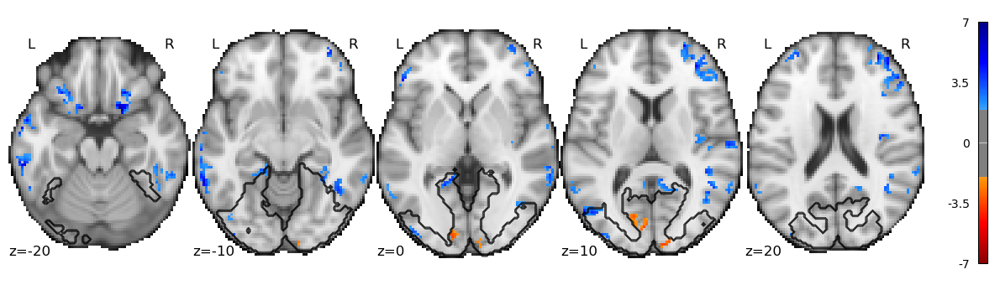

In [27]:
##Yeo's visual network
visual = os.path.join(derivatives_dir, 'Yeo2011_17Networks_MNI152_FreeSurferConformed2mm_MNI_visual.nii.gz')

## create mask ###
#########################
PLS_CMRO2_nii= results_dir + '/N'+str(len(sids)) +'_meanPLS_CMRO2_LV1_BSR_clust_z2.nii.gz'
GM_group_mask = os.path.join(derivatives_dir, 'task-loc_space-MNI152NLin6Asym_res-2_SNR_YEO_group_mask.nii.gz')
GLM_CMRO2_GMmask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_CMRO2__2ndlevel_GMmasked.nii.gz')
! fslmaths {PLS_CMRO2_nii} -mas {GM_group_mask} {GLM_CMRO2_GMmask}


##plot nicely
if design_scores_df_CMRO2.loc['checker'][1] > 0: #higher in calc
    my_color = colormap
else:
    my_color = colormap_r
    
axial_save_name = results_dir + '/N' + str(len(sids)) + '_PLS_BOLD_2ndlevel_2side_fdr_alpha05_axial_noCBV.pdf'
    
plotting.plot_img(GLM_CMRO2_GMmask, bg_img = MNI_2mm_brain,threshold = 2, display_mode='z', cmap=my_color, colorbar = True,
                        cut_coords = coords, vmax=7, vmin = -7,
                        output_file=axial_save_name)
plot = plotting.plot_img(GLM_CMRO2_GMmask, bg_img = MNI_2mm_brain,threshold = 2, display_mode='z', cmap=my_color, colorbar = True,
                        cut_coords = (-20, -10, 0, 10, 20), vmax=7, vmin = -7)
plot.add_contours(visual,  colors='black', alpha = 1, linewidths=0.3)

## then binarize and only take positive 
GLM_CMRO2_mask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_CMRO2__2ndlevel_mask.nii.gz')
! fslmaths {PLS_CMRO2_nii} -mas {GM_group_mask} -uthr {-2} -mul {-1} -bin {GLM_CMRO2_mask}


In [77]:

from matplotlib.colors import ListedColormap
newcmp_surface = ListedColormap(["lightgrey","darkorange", "darkorange", "darkorange"])

GLM_CMRO2_mask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_CMRO2__2ndlevel_mask.nii.gz')

maxval = 1
left_3D_name = results_dir + '/N' + str(len(sids)) + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_left_noCBV.pdf'
right_3D_name = results_dir + '/N' + str(len(sids)) + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_right_noCBV.pdf'

## 3D surface plot
texture_left = surface.vol_to_surf(GLM_CMRO2_mask, fsaverage['pial_left'],  interpolation="nearest") 
texture_right = surface.vol_to_surf(GLM_CMRO2_mask, fsaverage['pial_right'],interpolation="nearest")

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})

plot = plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4, vmax=maxval, threshold=0, 
                                cmap=newcmp_surface, axes=ax[0])

plot = plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1], 
                                output_file=left_3D_name)

plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='lateral', colorbar=False,
                               bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='lateral',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1],
                               output_file=right_3D_name)
plt.tight_layout() 

<Figure size 640x480 with 0 Axes>

#### get 2nd level CMRO2 mask into subject-level native T2 space

In [ ]:
## only positive values, binarized
PLS_CMRO2_nii_vismask= os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_CMRO2__2ndlevel_mask.nii.gz')

for ID in sids:
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    subid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
    print(subid)
    sid="sub-{:03d}".format(ID+8) 

    subjfolder = os.path.join(data_dir, 'derivatives', sub)

    
    ## output from fmriprep
    T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_deface.nii.gz')
    if not os.path.exists(T1w):
        T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w.nii.gz')

    br_mask=os.path.join(subjfolder, 'anat', sub + '_desc-brain_mask.nii.gz')

    ## from fmriprep: 
    MNI_to_T1w = os.path.join(subjfolder, 'anat', sub + '_from-MNI152NLin6Asym_to-T1w_mode-image_xfm.h5')

    ## apply transform: from MNI to T1w
    CMRO2mask_T1space = os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T1w.nii.gz')
    ! antsApplyTransforms -d 3 --float 1 --verbose 1 -i {PLS_CMRO2_nii_vismask} -r {T1w} -t {MNI_to_T1w} -o {CMRO2mask_T1space}
    

    ## plot results
    plot = plotting.plot_img(CMRO2mask_T1space, bg_img = T1w,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sid + ' CMRO2 mask T1w space')   

    
    ## get into T2 space
    T1w_brain=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_brain.nii.gz')
    T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   
    T1w_T2space_brain=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w_brain.nii.gz')
    T1_to_T2 =os.path.join(subjfolder, 'anat', sub + '_from_T1w_2_T2space.mat')
    CMRO2mask_T2space = os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')
    ! flirt -in {T1w_brain} -ref {T1w_T2space_brain} -omat {T1_to_T2} -dof 6 -interp nearestneighbour
    
    ! flirt -in {CMRO2mask_T1space} -ref {T1w_T2space} -applyxfm -init  {T1_to_T2} -out {CMRO2mask_T2space} -interp nearestneighbour
    ## plot results
    plot = plotting.plot_img(CMRO2mask_T2space, bg_img = T1w_T2space_brain,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sub + 'CMRO2 mask T2 space')

#### apply qBOLD masking

In [29]:
## run qBOLD toolbox
%run qBOLD_fun.ipynb

#grey matter mask
GMthresh = 0.5; #mandatory

#mask CSF influenced areas
T2thresh = 150; #mandatory

#mask R2strich artifact areas
R2thresh = 11 ; #mandatory

#mask CBV 
CBVthresh = 12; #optional: comment out if not used, default = 20

#mask T2S
T2Sthresh = 90; #optional: comment out if not used, default = 150

#mask OEF
OEFthresh = 1; #optional: comment out if not used, default = 1

#mask CBF
CBFthresh = 120; #optional: comment out if not used, default = 150

Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply 

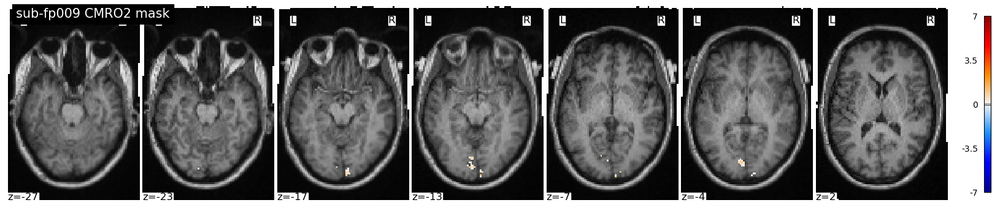

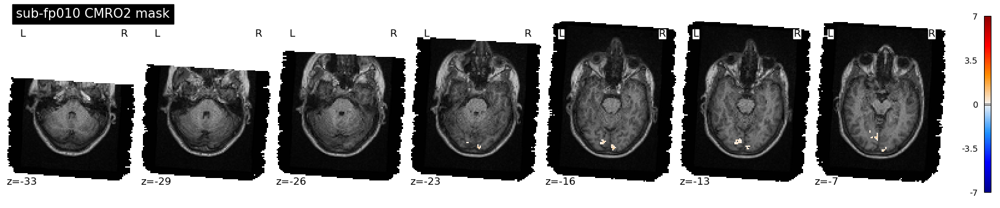

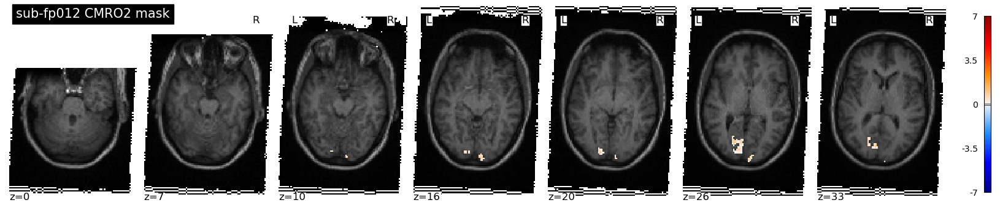

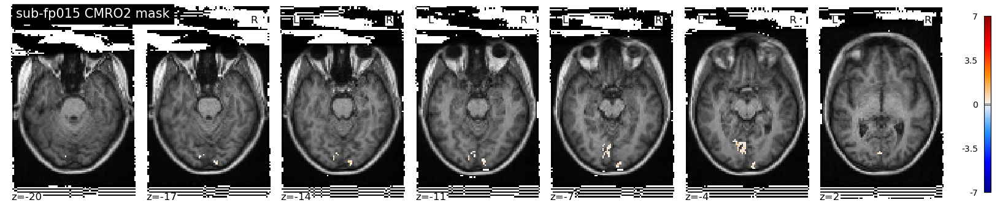

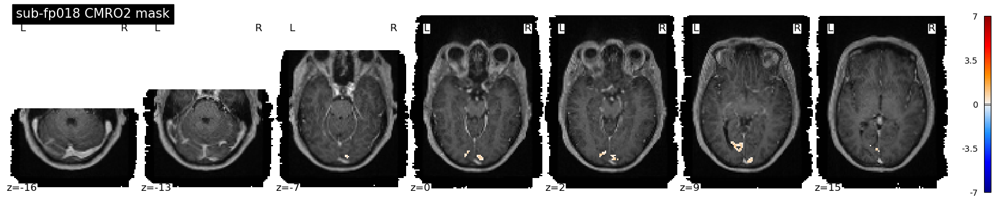

...

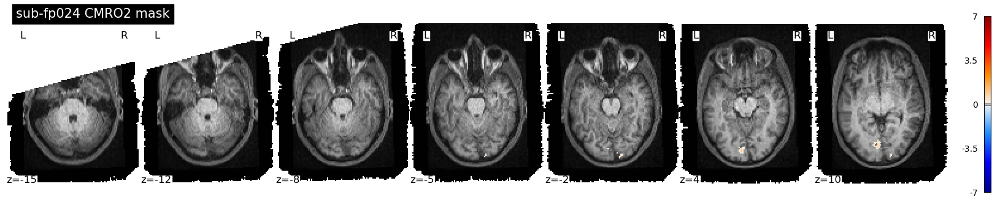

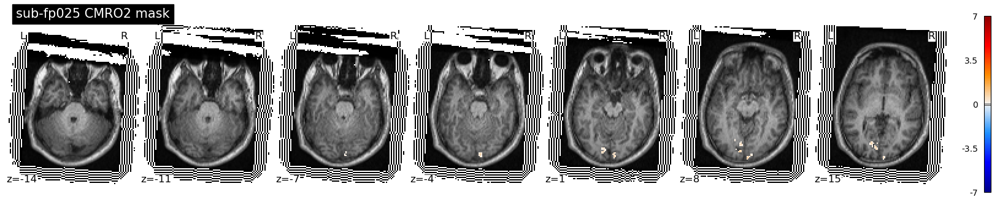

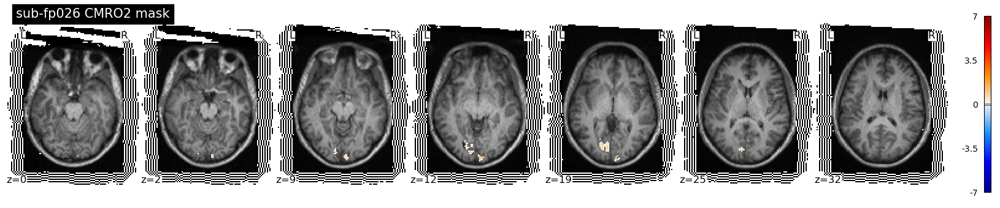

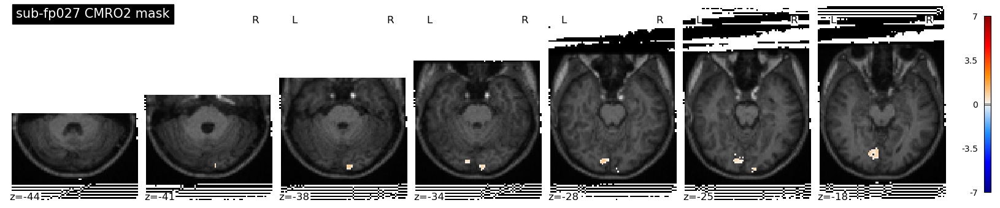

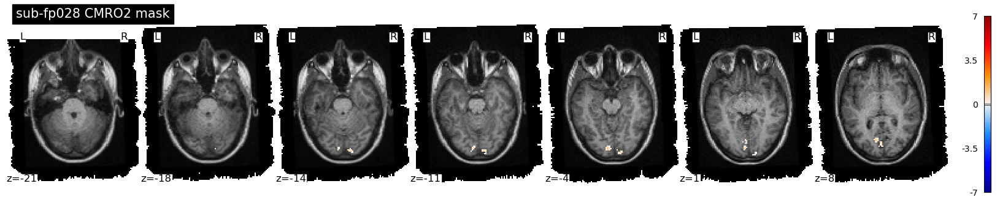

In [30]:
## mask the native-space visual activation 
for i, ID in enumerate(sids): #loop over subjects
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'

    subjfolder = os.path.join(data_dir, 'derivatives', sub)
    T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   

    mask_list = create_qBOLD_masks(sub, subjfolder, conds, GMthresh, T2thresh, R2thresh, CBVthresh, T2Sthresh, OEFthresh,  CBFthresh=None)                
    CMRO2mask_T2space = os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')

    ##mask parameter map
    out_name = CMRO2mask_T2space[:-7] + '_qBmasked.nii.gz'
    par_masked = mask_nii(CMRO2mask_T2space, mask_list, out_name)
        
    plotting.plot_img(par_masked, bg_img = T1w_T2space, threshold=0.1, vmin=-7, vmax=7, display_mode='z', cmap=BlueRed, colorbar=True, title = sub + ' CMRO2 mask')


## 4. CBF mask

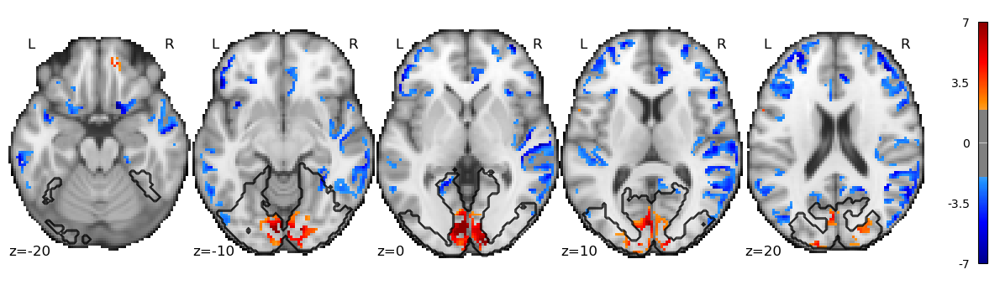

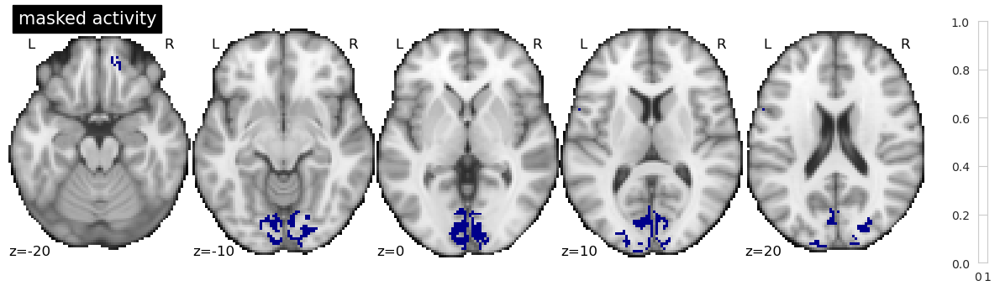

In [31]:
##Yeo's visual network
visual = os.path.join(derivatives_dir, 'Yeo2011_17Networks_MNI152_FreeSurferConformed2mm_MNI_visual.nii.gz')

## create mask ###
#########################
PLS_CBF_nii= results_dir + '/N'+str(len(sids)) +'_meanPLS_CBF_LV1_BSR_clust_z2.nii.gz'
GM_group_mask = os.path.join(derivatives_dir, 'task-loc_space-MNI152NLin6Asym_res-2_SNR_YEO_group_mask.nii.gz')
GLM_CBF_mask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_CBF_2ndlevel_mask.nii.gz')
GLM_CBF_GMmask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_CBF_2ndlevel_GMmasked.nii.gz')
! fslmaths {PLS_CBF_nii} -mas {GM_group_mask}  {GLM_CBF_GMmask}

##plot nicely
axial_save_name = results_dir + '/N' + str(len(sids)) + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_axial_noCBV.pdf'
    
plotting.plot_img(GLM_CBF_GMmask, bg_img = MNI_2mm_brain,threshold = 2, display_mode='z', cmap=BlueRed, colorbar = True,
                        cut_coords = coords, vmax=7, vmin = -7,
                        output_file=axial_save_name)
plot = plotting.plot_img(GLM_CBF_GMmask, bg_img = MNI_2mm_brain,threshold = 2, display_mode='z', cmap=BlueRed, colorbar = True,
                        cut_coords = (-20, -10, 0, 10, 20), vmax=7, vmin = -7)
plot.add_contours(visual,  colors='black', alpha = 1, linewidths=0.3)

## then binarize and only take positive 
! fslmaths {PLS_CBF_nii} -mas {GM_group_mask} -thr {2} -bin {GLM_CBF_mask}


plotting.plot_img(GLM_CBF_mask, display_mode='z', bg_img=MNI_2mm_brain, threshold=0, cmap=BlueRed, cut_coords=(-20, -10, 0, 10, 20),
                colorbar=True, title="masked activity")



In [128]:

from matplotlib.colors import ListedColormap
newcmp_surface = ListedColormap(["lightgrey","darkorange", "darkorange", "darkorange"])


maxval = 1
left_3D_name = results_dir + '/N' + str(len(sids)) + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_left_noCBV.pdf'
right_3D_name = results_dir + '/N' + str(len(sids)) + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_right_noCBV.pdf'

## 3D surface plot
texture_left = surface.vol_to_surf(GLM_CBF_mask, fsaverage['pial_left'],  interpolation="nearest") 
texture_right = surface.vol_to_surf(GLM_CBF_mask, fsaverage['pial_right'],interpolation="nearest")

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})

plot = plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4, vmax=maxval, threshold=0, 
                                cmap=newcmp_surface, axes=ax[0])

plot = plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='medial',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1], 
                                output_file=left_3D_name)

plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 10), ncols=2, subplot_kw={"projection": "3d"})
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left,
                               hemi='left', view='lateral', colorbar=False,
                               bg_map=fsaverage['sulc_left'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right,
                               hemi='right', view='lateral',colorbar=False,
                                bg_map=fsaverage['sulc_right'], bg_on_data=True,
                               darkness=.4,  vmax=maxval, threshold=0,
                                cmap=newcmp_surface, axes=ax[1],
                               output_file=right_3D_name)
plt.tight_layout() 

<Figure size 640x480 with 0 Axes>

### get 2nd level CBF mask into subject-level T2 space

In [ ]:
## only positive values, binarized
PLS_CBF_nii_vismask= os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_CBF_2ndlevel_mask.nii.gz')

for ID in sids:
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    subid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
    print(subid)
    sid="sub-{:03d}".format(ID+8) 

    subjfolder = os.path.join(data_dir, 'derivatives', sub)

    
    ## output from fmriprep
    T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_deface.nii.gz')
    if not os.path.exists(T1w):
        T1w=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w.nii.gz')

    br_mask=os.path.join(subjfolder, 'anat', sub + '_desc-brain_mask.nii.gz')

    ## from fmriprep: 
    MNI_to_T1w = os.path.join(subjfolder, 'anat', sub + '_from-MNI152NLin6Asym_to-T1w_mode-image_xfm.h5')

    ## apply transform: from MNI to T1w
    CBFmask_T1space = os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T1w.nii.gz')
    ! antsApplyTransforms -d 3 --float 1 --verbose 1 -i {PLS_CBF_nii_vismask} -r {T1w} -t {MNI_to_T1w} -o {CBFmask_T1space}
    

    ## plot results
    plot = plotting.plot_img(CBFmask_T1space, bg_img = T1w,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sid + ' CBF mask T1w space')   

    
    ## get into T2 space
    T1w_brain=os.path.join(subjfolder, 'anat', sub + '_desc-preproc_T1w_brain.nii.gz')
    T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   
    T1w_T2space_brain=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w_brain.nii.gz')
    T1_to_T2 =os.path.join(subjfolder, 'anat', sub + '_from_T1w_2_T2space.mat')
    CBFmask_T2space = os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')
    ! flirt -in {T1w_brain} -ref {T1w_T2space_brain} -omat {T1_to_T2} -dof 6 -interp nearestneighbour
    
    ! flirt -in {CBFmask_T1space} -ref {T1w_T2space} -applyxfm -init  {T1_to_T2} -out {CBFmask_T2space} -interp nearestneighbour
    ## plot results
    plot = plotting.plot_img(CBFmask_T2space, bg_img = T1w_T2space_brain,display_mode='z', vmax=7, vmin = -7, threshold=0.1,
                            cmap=BlueRed, colorbar = True, title=sid + 'CBF mask T2 space')

### apply qBOLD-masking

In [32]:
## mask the native-space visual activation 
for i, ID in enumerate(sids): #loop over subjects
    sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
    sid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
    print(sid)
    subjfolder = os.path.join(data_dir, 'derivatives', sub)
    T1w_T2space=os.path.join(subjfolder, 'qmri', sub + '_space-T2_T1w.nii')   
    
    mask_list = create_qBOLD_masks(sub, subjfolder, conds, GMthresh, T2thresh, R2thresh, CBVthresh, T2Sthresh, OEFthresh,  CBFthresh=None)                
    CBFmask_T2space = os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2.nii.gz')

    ##mask parameter map
    out_name = CBFmask_T2space[:-7] + '_qBmasked.nii.gz'
    par_masked = mask_nii(CBFmask_T2space, mask_list, out_name)
        


sub-fp001
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp002
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp004
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp007
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp010
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp011
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp014
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp015
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp016
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp017
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply mask: 3
Apply mask: 4
Apply mask: 5
sub-fp018
Apply mask: 0
Apply mask: 1
Apply mask: 2
Apply ma

### 5. OEF mask

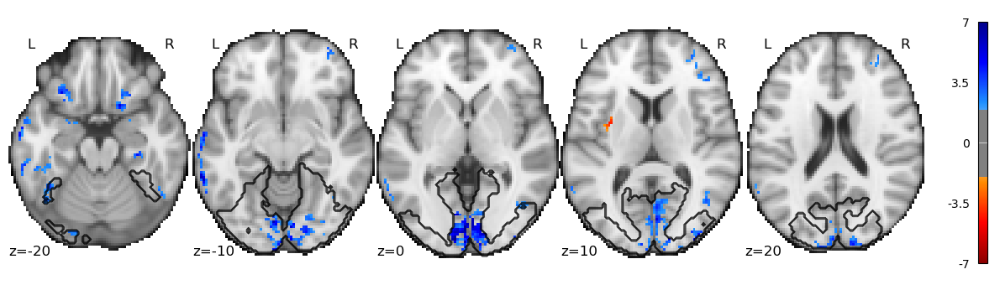

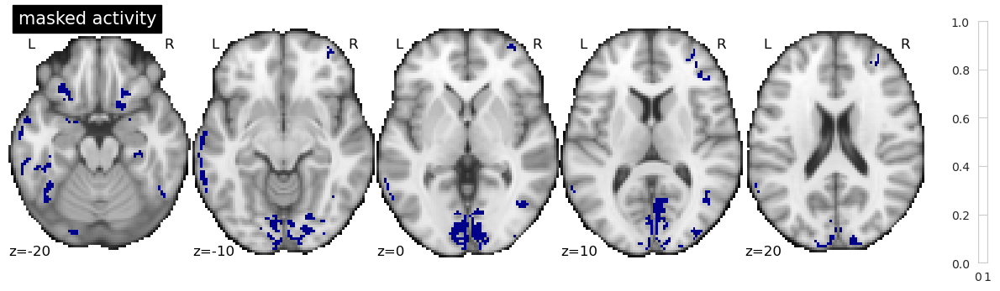

In [105]:
##Yeo's visual network
visual = os.path.join(derivatives_dir, 'Yeo2011_17Networks_MNI152_FreeSurferConformed2mm_MNI_visual.nii.gz')

## create mask ###
#########################
PLS_OEF_nii=os.path.join( results_dir, 'N' + str(len(sids))  + '_meanPLS_OEF_LV1_BSR_clust_z' + str(BSR_thr)+ '_noCBVmask.nii.gz')
GM_group_mask = os.path.join(derivatives_dir, 'task-loc_space-MNI152NLin6Asym_res-2_SNR_YEO_group_mask.nii.gz')
GLM_OEF_GMmask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_OEF_2ndlevel_GMmasked.nii.gz')
! fslmaths {PLS_OEF_nii} -mas {GM_group_mask}  {GLM_OEF_GMmask}

##plot nicely
if design_scores_df_OEF.loc['checker'][1] > 0: #higher in calc
    my_color = colormap
else:
    my_color = colormap_r
    
axial_save_name = results_dir + '/N' + str(len(sids)) + '_PLS_OEF_2ndlevel_2side_fdr_alpha05_axial_noCBV.pdf'
    
plotting.plot_img(GLM_OEF_GMmask, bg_img = MNI_2mm_brain,threshold = 2, display_mode='z', cmap=my_color, colorbar = True,
                        cut_coords = coords, vmax=7, vmin = -7,
                        output_file=axial_save_name)
plot = plotting.plot_img(GLM_OEF_GMmask, bg_img = MNI_2mm_brain,threshold = 2, display_mode='z', cmap=my_color, colorbar = True,
                        cut_coords = (-20, -10, 0, 10, 20), vmax=7, vmin = -7)
plot.add_contours(visual,  colors='black', alpha = 1, linewidths=0.3)

## then binarize and only take positive 
GLM_OEF_mask = os.path.join(derivatives_dir, 'N'+str(len(sids))+ '_PLS_OEF_2ndlevel_mask.nii.gz')
! fslmaths {GLM_OEF_GMmask} -thr {2} -bin {GLM_OEF_mask}


plotting.plot_img(GLM_OEF_mask, display_mode='z', bg_img=MNI_2mm_brain, threshold=0, cmap=BlueRed, cut_coords=(-20, -10, 0, 10, 20),
                colorbar=True, title="masked activity")
#plot.add_contours(visual,  colors='black', alpha = 1, linewidths=0.3)

#! fslmaths {GLM_CMRO2_GMmask} -uthr {-2} -abs -bin {GLM_CMRO2_mask}


# Fig 2: boxplots

par  =cmrglc
mask = BOLD
sub-fp001
sub-fp003
sub-fp004
sub-fp007
sub-fp009
sub-fp010
sub-fp011
sub-fp013
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
cmrglc % open = 36.4952761332194 +/- 5.963580875379878
cmrglc % checker = 42.699702453613284 +/- 7.982418288351975
7.1855507582731795
4.6687430358313554e-06
mask = fPET
sub-fp001
sub-fp003
sub-fp004
sub-fp007
sub-fp009
sub-fp010
sub-fp011
sub-fp013
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
cmrglc % open = 40.26100540161133 +/- 7.008401793399469
cmrglc % checker = 50.76806081136068 +/- 11.100098965883316
6.763902471672115
9.112279359402778e-06
mask = CMRO2
sub-fp001
sub-fp003
sub-fp004
sub-fp007
sub-fp009
sub-fp010
sub-fp011
sub-fp013
sub-fp014
sub-fp015
sub-fp016
sub-fp017
sub-fp018
sub-fp019
sub-fp020
cmrglc % open = 42.56604258219401 +/- 7.686340270307642
cmrglc % checker = 54.016273752848306 +/- 12.321806489575678
6.475095739736627
1.4606991548405727e-05
mask = CBF
sub-fp001
sub-fp00

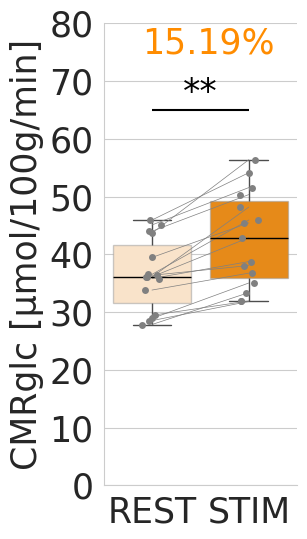

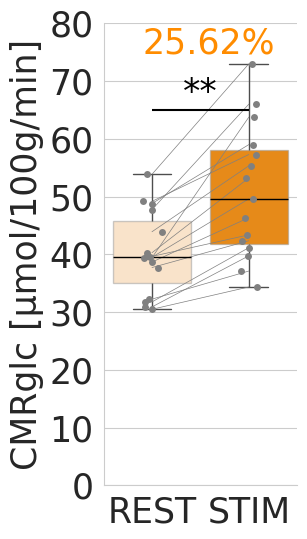

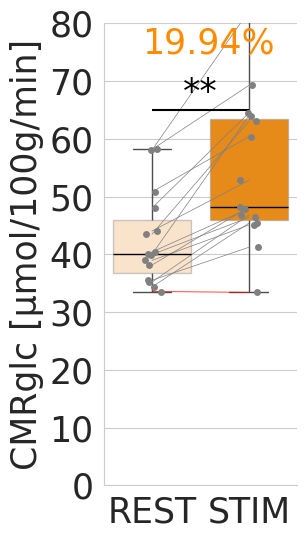

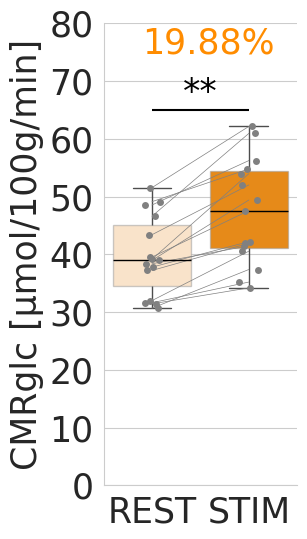

In [6]:
## mask parameter maps with z-stat mask (qB masked)
parameters = ['BOLD','cmrglc','cmro2',  'cbf',  'oef']
parameters = ['cmrglc']
#parameters = ['cmro2_without_cbv'] ## cmro2 change without taking deltaCBV into account

labels=['REST', 'STIM']
fontsize = 25
sns.set_style("whitegrid")
##define your colour palette

my_colors_act = [ 'bisque', 'darkorange']
my_colors_deact = [ 'lightskyblue', 'dodgerblue']

masks=['BOLD', 'fPET', 'CMRO2', 'CBF']
#masks=['fPET', 'CMRO2', 'CBF']

#

for p, par in enumerate(parameters): 
    print('par  =' +par)
    if par != 'cmrglc':
        subjects=sids
    if par == 'cmrglc':
        subjects=sids_cmrglc
    median_perchange = np.zeros((len(parameters), len(subjects)))

    for m, mask in enumerate(masks):
        print('mask = ' + mask)    
            
        percchange = np.zeros((len(subjects)))   
        par_rest_masked = np.zeros((len(subjects))) 
        par_task_masked = np.zeros((len(subjects))) 
        
        for i, ID in enumerate(subjects): #loop over subjects
            sub = "sub-fp{:03d}".format(ID+8) # subject id, eg 'p021'
            subid = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
            print(subid)
            sid = "fp{:03d}".format(ID+8) # subject id, eg 'p021'
            
            subjfolder = os.path.join(data_dir, 'derivatives', sub)
            dir_deriv = os.path.join(derivatives_dir, sub)
    
            if mask == 'BOLD':
                zstat_mask = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')
                zstat_mask_bin = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
            
            if mask == 'fPET':
                zstat_mask =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

            if mask == 'CMRO2':
                zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
                
            if mask == 'CBF':
                zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
                ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

            if mask == 'CBV':
                zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CBV_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CBV_2ndlevel_2side_fdr_alpha05_vismask_space-T2_bin.nii.gz')
                ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
                
            if mask == 'totalCBV':
                zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_totalCBV_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
                zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_totalCBV_2ndlevel_2side_fdr_alpha05_vismask_space-T2_bin.nii.gz')
                ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
                masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
                
            T1w = os.path.join(dir_deriv, 'qmri',  sub + '_space-T2_T1w.nii')
        
            #plotting.plot_roi(zstat_mask, bg_img=T1w, threshold=0, vmin=-3, vmax=3,  cmap=BlueRed, cut_coords=(0, 10, 20, 30, 40, 50, 60), display_mode='z',colorbar = True, title=sub)
        
            ################
            ## BOLD ########
            ################
            
            if par == 'BOLD':
                ## download normalized fMRI localizer
                localizer =  os.path.join(dir_deriv, 'func', sub + '_task-loc_space-T2_desc-preproc_bold.nii.gz')
    
                ## apply GM mask (with GM_thr defined)
                localizer_arr = masker_1stlevel.fit_transform(localizer)
    
                #############################################################
                ##create percent signal change values (baseline = median across time) ##
                #############################################################
                
                ## median across all voxels within 1st level mask
                ROI_timeseries = np.nanmedian(localizer_arr, axis=1) #median across voxels per ROI
    
                ## TR = 2, 15 TR per conditions
                #baseline: median of rest condition
                visstim = (ROI_timeseries[list(range(5, 15)) + list(range(35, 45)) + list(range(65, 75)) + list(range(95, 105))])  
                baseline_open = np.median(ROI_timeseries[list(range(20, 30)) + list(range(50, 60)) + list(range(80, 90)) + list(range(110, 120))]) 

                ## store in array for every subject
                perc_visstim = 100* (visstim - baseline_open) / baseline_open
                par_median = np.nanmedian(perc_visstim[perc_visstim!=0], axis=0)
                percchange[i] = np.nanmedian(par_median)
                median_perchange[p, i] = percchange[i]
            
            ############################
            ## other parameters ########
            ############################
            
            if par != 'BOLD':
                par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_'+par+'.nii')
                if par == 'cmrglc':
                    par_rest =  os.path.join(dir_deriv, 'fpet', sub + '_glm_task-open_space-T2_'+par+'.nii.gz')
                    par_task = os.path.join(dir_deriv, 'fpet', sub+ '_glm_task-checker_space-T2_'+par+'.nii.gz')
                if par == 'cmro2_without_cbv':
                    par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_cmro2.nii')
                    par_task = os.path.join('/home/tumnic/sepp/neuroenergeticslab_notebooks/p_fpet_vis/tmp/'+sid+'/qBOLD/task-checker/CMRO2_noCBV.nii.gz') 

                if par == 'cbf':
                    par_task =  os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_'+par+'.nii')              
                if par != 'cbf' and par !='cmrglc':              
                    par_task = os.path.join(dir_deriv, 'qmri', sub+'_task-checker_space-T2_desc-30perc_'+par+'.nii')
                if par == 'totalcbv':
                    par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_cbv.nii')
                    par_task = os.path.join(dir_deriv, 'qmri', sub+'_task-checker_space-T2_cbv.nii')

                            
                ## mask arrays with visual stimulation ROI
                par_task_masked[i] = np.nanmedian(masker_1stlevel.fit_transform(par_task))
                par_rest_masked[i] = np.nanmedian(masker_1stlevel.fit_transform(par_rest))
    
                percchange_par = (par_task_masked[i] - par_rest_masked[i]) / par_rest_masked[i] * 100
    
                ## store in array for every subject
                percchange[i] = np.nanmedian(percchange_par)
                median_perchange[p, i] = percchange[i]
    
    
        ##########
        ## plot ##
        ##########
    
        if par == 'BOLD':
            
            fig, ax = plt.subplots(1, 1, figsize=(1.5,6))
    
            colors = ['darkorange']
    
            sns.boxplot(data = percchange,  orient='v', ax=ax,palette=colors, saturation=0.8,
                               boxprops={"edgecolor": (.6, .6, .6, .5)}, flierprops={"marker": "x"},
                               medianprops={"color": "black"})
            sns.swarmplot(data = percchange, orient='v', ax=ax, color='grey')
            plt.hlines(0, -0.6, 0.6, color='black', alpha=0.8, linestyles='dashed')
            ax.text(-0.3, 3.5, str(round(np.median(percchange), 2))+' %', color=colors[0], fontsize=fontsize)
    
            for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                        label.set_fontsize(fontsize)
            ax.set_ylabel('BOLD [%]', fontsize=fontsize)
            ax.set_ylim(0,4)
                #ax.set_title(ROI + ' region: ' + contrast)
    
            for pos in ['right', 'top']:
                ax.spines[pos].set_visible(False)
    
            ax.set_xticklabels([labels[1]])
    
            fig.show()
            print( ' BOLD % change = '+ str(np.median(percchange)))
            print( ' BOLD % mean = '+ str(np.mean(percchange)) + ' +/- ' + str(np.std(percchange)))
    
            fig.savefig(os.path.join(results_dir, 'N'+str(len(subjects)) + '_ROIanalysis_BOLD_visstim'+mask+'.png'), dpi=300, bbox_inches='tight')
               
    
        if par != 'BOLD':
            
            ## significance: paired t-tests
            [tvalue, pvalue] = stats.ttest_rel(par_task_masked, par_rest_masked)
    
            print(par + ' % open = '+ str(np.mean(par_rest_masked)) + ' +/- ' + str(np.std(par_rest_masked) ))
            print(par + ' % checker = '+ str(np.mean(par_task_masked)) + ' +/- ' + str(np.std(par_task_masked) ))
            print(tvalue)
            print(pvalue)
    
    
            colors=my_colors_act
            ID_colour_code=[]
            for s in range(0, len(subjects)):
                if par !='oef':
                    if par_task_masked[s] - par_rest_masked[s]>0:
                                ID_colour_code.append('gray')
                    if par_task_masked[s] - par_rest_masked[s]<0:
                                ID_colour_code.append('red')        
                if par =='oef': ##here, negative values are expected, so color-coding is inverted
                    if par_task_masked[s] - par_rest_masked[s]<0:
                                ID_colour_code.append('gray')
                    if par_task_masked[s] - par_rest_masked[s]>0:
                                ID_colour_code.append('red') 
    
            fig, ax = plt.subplots(1,figsize=(2.5,6))
            sns.boxplot(data = [par_rest_masked, par_task_masked],  orient='v', ax=ax,palette=colors, saturation=0.8,
                               boxprops={"edgecolor": (.6, .6, .6, .5)}, flierprops={"marker": "x"},
                               medianprops={"color": "black"})
            sns.stripplot(data = [par_rest_masked, par_task_masked], orient='v', ax=ax, color='grey')
            for line, ID in enumerate(subjects): # for each subject separately
                    ax.plot([0, 1], [par_rest_masked[line], par_task_masked[line]],   
                              linewidth=0.5, color=ID_colour_code[line]) #plot lines = subjects 
    
            ## plot significance
            if par == 'cmro2' or par == 'cmro2_without_cbv':
                xval=300
                xlabel='CMRO2 [μmol/100g/min]'
                ylimit=350
            if par == 'cbf':
                xval=80
                xlabel='CBF [ml/100g/min]'
                ylimit=100
            if par == 'cbv' or par == 'totalcbv':
                xval=6
                xlabel='CBV [%vol]'
                ylimit=6.5
            if par == 'oef':
                xval=0.65
                xlabel='OEF [ratio]'
                ylimit=0.65
            if par == 'cmrglc':
                xval=65
                xlabel='CMRglc [μmol/100g/min]'
                ylimit=80                
    
            if pvalue<0.001:
                    ax.text(0.5, xval, "**", ha='center', va='bottom', color='black', fontsize=fontsize)
                    ax.hlines(xval, 0, 1, color='black')

            if pvalue<0.05 and pvalue>0.001:
                    ax.text(0.5, xval, "*", ha='center', va='bottom', color='black', fontsize=fontsize)
                    ax.hlines(xval, 0, 1, color='black')
    
            if par !='oef':
                ax.text(-0.1, xval + (0.15*xval) , str(round(np.nanmedian(percchange), 2))+'%', color=colors[1], fontsize=fontsize, alpha=1)
            if par == 'oef':
                ax.text(-0.1, xval - (0.6*xval) , str(round(np.nanmedian(percchange), 2))+'%', color=colors[1], fontsize=fontsize, alpha=1)
            ax.set_ylim(0, ylimit)
                
            ax.set_ylabel(xlabel, fontsize=fontsize)
            ax.set_xlim(-0.5, 1.5)
            ax.set_xticks((0,1), labels=labels)
            ax.set_xticklabels(['REST', 'STIM'], size = fontsize)
    
            for pos in ['right', 'top']:
                        ax.spines[pos].set_visible(False)
    
            for label in (ax.get_xticklabels() + ax.get_yticklabels()):
                        label.set_fontsize(fontsize)
    
            fig.show()
    
            fig.savefig(os.path.join(results_dir,  'N'+str(len(subjects)) + '_ROIanalysis_'+par+'_ROI_visstim_'+mask+'.png'), dpi=300, bbox_inches='tight')

    np.save(os.path.join(results_dir, 'N'+str(len(subjects)) + '_mask' +mask+'.npy' ), median_perchange)


## Fig 2 C: line plots with mean %change values across different masks

Index(['mask', 'parameter', 'perc_change', 'hedges'], dtype='object')
   mask parameter  perc_change    hedges
0  BOLD       cbf    10.242337  0.404629
1  BOLD    cmrglc    11.856084  0.743126
2  BOLD     cmro2     3.126977  0.047935
3  BOLD       oef    -7.273685 -0.640306
4   CBF       cbf    13.607112  0.570294


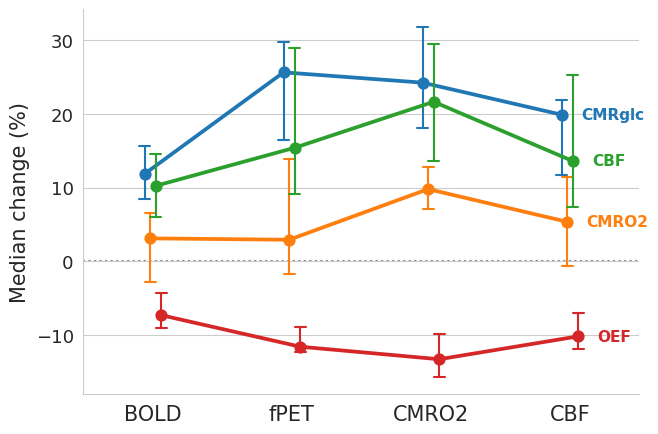

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------

mask_names = ['BOLD', 'fPET', 'CMRO2', 'CBF']

parameter_names = ['BOLD', 'cmrglc', 'cmro2', 'cbf', 'oef']

plot_parameters = ['cmrglc', 'cmro2', 'cbf', 'oef']

colors = {
    'cmrglc': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
    'cmro2':  (1.0, 0.4980392156862745, 0.054901960784313725),
    'cbf':    (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
    'oef':    (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)
}

parameter_labels = {
    'cmrglc': 'CMRglc',
    'cmro2':  'CMRO2',
    'cbf':    'CBF',
    'oef':    'OEF'
}


# ------------------------------------------------------------
# Load effect sizes
# ------------------------------------------------------------

effectsize_file = '/RAID1/jupytertmp/p_fpet_vis/summary_perc_change_effectSizes.csv'

df_effect = pd.read_csv(effectsize_file)

# Check once that these are the actual column names in your CSV
print(df_effect.columns)
print(df_effect.head())


# ------------------------------------------------------------
# Load data and convert to long format
# ------------------------------------------------------------

data_long = []

for mask in mask_names:

    filename = os.path.join(
        results_dir,
        'mask' + mask + '.npy'
    )

    mask_median = np.load(filename)

    for parameter in plot_parameters:

        p = parameter_names.index(parameter)

        values = mask_median[p, :]
        values = values[np.isfinite(values)]

        for value in values:

            data_long.append({
                'mask': mask,
                'parameter': parameter,
                'percent_change': value
            })


df = pd.DataFrame(data_long)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

sns.pointplot(
    data=df,
    x='mask',
    y='percent_change',
    hue='parameter',

    # median across subjects
    estimator=np.nanmedian,

    # 95% bootstrap confidence interval
    errorbar=('ci', 95),
    n_boot=10000,
    seed=42,

    # only minimal horizontal separation
    dodge=0.12,

    palette=colors,

    markers='o',
    linestyles='-',
    capsize=0.08,
    err_kws={'linewidth': 1.5},
    ax=ax
)


# ------------------------------------------------------------
# Offsets corresponding approximately to dodge=0.12
# ------------------------------------------------------------

n_parameters = len(plot_parameters)

offsets = np.linspace(
    -0.06,
    0.06,
    n_parameters
)


# ------------------------------------------------------------
# Add EFFECT SIZE values above/left of each point
# ------------------------------------------------------------

for j, parameter in enumerate(plot_parameters):

    for i, mask in enumerate(mask_names):

        # Median determines WHERE the label is placed
        values = df.loc[
            (df['mask'] == mask) &
            (df['parameter'] == parameter),
            'percent_change'
        ]

        if len(values) > 0:

            median_value = np.nanmedian(values)

            # ----------------------------------------------
            # Find corresponding effect size
            #
            # Assumes CSV columns:
            #   mask
            #   parameter
            #   effect_size
            # ----------------------------------------------

            effect_row = df_effect.loc[
                (df_effect['mask'].str.lower() == mask.lower()) &
                (df_effect['parameter'].str.lower() == parameter.lower())
            ]

            if len(effect_row) > 0:

                effect_size = effect_row['hedges'].iloc[0]

                #ax.annotate(
                #    f'{effect_size:.2f}',
                #    xy=(i + offsets[j], median_value),#

                    # move text left and slightly up
               #     xytext=(-12, 6),

                #    textcoords='offset points',
                 #   ha='right',
                 #   va='bottom',

                  #  color=colors[parameter],
                  #  fontsize=10
                #)


# ------------------------------------------------------------
# Remove legend
# ------------------------------------------------------------

if ax.get_legend() is not None:
    ax.get_legend().remove()


# ------------------------------------------------------------
# Add parameter names to RIGHT of plot
# ------------------------------------------------------------

last_mask = mask_names[-1]
last_x = len(mask_names) - 1

for j, parameter in enumerate(plot_parameters):

    values = df.loc[
        (df['mask'] == last_mask) &
        (df['parameter'] == parameter),
        'percent_change'
    ]

    if len(values) > 0:

        median_value = np.nanmedian(values)

        ax.annotate(
            parameter_labels[parameter],
            xy=(last_x + offsets[j], median_value),
            xytext=(14, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            color=colors[parameter],
            fontsize=11,
            fontweight='bold',
            annotation_clip=False
        )


# ------------------------------------------------------------
# 0% reference line
# ------------------------------------------------------------

ax.axhline(
    0,
    color='gray',
    linestyle=':',
    linewidth=1.5,
    zorder=0
)


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel('')
ax.set_ylabel('Median change (%)', fontsize=15)

ax.set_xticks(np.arange(len(mask_names)))
ax.set_xticklabels(mask_names, fontsize=15)

ax.tick_params(axis='y', labelsize=13)


# ------------------------------------------------------------
# Cosmetics
# ------------------------------------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(right=0.82)

plt.show()

# 

### changes in cbv (subj ids change)

In [ ]:
## CBV

fontsize = 20
plt.rcParams['legend.title_fontsize'] = 'x-large'
sns.set_style("whitegrid")
BSR_thr = 2


GM_mask = os.path.join(derivatives_dir, 'N16_space-MNI152_SNR_YEO_CBV_mask.nii.gz')

mask_img = nib.load(GM_mask)
masker = input_data.NiftiMasker(mask_img=GM_mask) ## exclude areas with too less SNR (based on the localizer data)
mask_arr = np.array(mask_img.dataobj)


##########################################################
## please select which group task mask to apply!! ##
##########################################################

masks=['BOLD', 'fPET', 'CMRO2', 'CBF']


##########################################################
## please select which parameters you want to look at! ##
##########################################################

parameters = ['cbv']


for mask in masks:
    print(mask)
    
   if mask == 'BOLD':
        zstat_mask = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')
        zstat_mask_bin = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
    
    if mask == 'fPET':
        zstat_mask =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
        zstat_mask_bin =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

    if mask == 'CMRO2':
        zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
        zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
        
    if mask == 'CBF':
        zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
        zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
        
    masker_pos = input_data.NiftiMasker(mask_img = BSR_nii)    

    for par in parameters: 
        print(par)
        percchange_pos = np.zeros((len(sids_cbv), len(np.argwhere(np.array(BSR_nii.dataobj)))))   
        delta_masked = np.zeros((len(sids_cbv), len(np.argwhere(np.array(BSR_nii.dataobj)))))   

        for i, ID in enumerate(sids_cbv): #loop over subjects
            sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
            print(sub)

            sub_dir = os.path.join(data_dir, sub)
            dir_deriv = os.path.join(derivatives_dir, sub)


            par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-MNI152_'+par+'.nii.gz')
            par_task = os.path.join(dir_deriv, 'qmri', sub+'_task-checker_space-MNI152_desc-30perc_'+par+'.nii.gz')
    
            ## mask arrays with visual stimulation ROI
            par_task_masked = masker_pos.fit_transform(par_task)
            par_rest_masked = masker_pos.fit_transform(par_rest)
                
            percchange_par = (par_task_masked - par_rest_masked) / par_rest_masked * 100
            delta_masked[i, :] = par_task_masked - par_rest_masked
                
            ## store in array for every subject
            percchange_pos[i, :] = percchange_par

                  
        ## calculate median values across subjects, per voxel
        percchange_median = np.nanmedian(percchange_pos, axis=0)
        delta_median = np.nanmedian(delta_masked, axis=0)
               

        ## plot percchange values ##
        ############################
        
        fig,ax = plt.subplots(1)      
        
        width = 0.02
        brange= (-1, 1.5)
        ax.set_xlim(-1, 1.5)
        ax.set_xticks([-0.5, 0, 0.5, 1, 1.5, 2, 2.5])
        axis_title = 'ΔCBV'            
        max_val = 150
        if mask == 'PLS_CMRglc':
            max_val=25 


        sns.histplot(delta_median, ax=ax, color='darkorange', alpha=0.9, bins=500, binrange = brange, binwidth= width)
        ax.plot([np.nanmedian(delta_median), np.nanmedian(delta_median)], [0, max_val], color='darkred')
        
        ax.set_xlabel(axis_title, fontsize=fontsize)
        ax.set_ylabel('voxel count', fontsize=fontsize)
        # absolute median values as text in plot
        ax.text(brange[1]-0.6*brange[1], max_val, str(round(np.nanmedian(delta_median), 1))+' ΔCBV', color='red', fontsize=fontsize)
        ax.text(brange[1]-0.6*brange[1], max_val - (0.12 * max_val), str(round(np.nanmedian(percchange_median), 1))+' %', color='darkorange', fontsize=fontsize)                
        plt.vlines(np.nanmedian(delta_median), 0, max_val, color='red', alpha=0.7, linestyles='solid')
        
        plt.vlines(0, 0, max_val, color='gray', alpha=0.7, linestyles='dashed')
        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontsize(fontsize)

       
        for pos in ['right', 'top']:
            ax.spines[pos].set_visible(False)

        fig.show()
        if CBV_masking == 'yes':
            fig.savefig(results_dir + '/N' + str(len(sids_cbv)) +'_mask_'  + mask + '_visstim' + '_' + par+'_histogram.png', dpi=300, bbox_inches='tight')
        if CBV_masking == 'no':
            fig.savefig(results_dir + '/N' + str(len(sids_cbv)) +'_mask_'  + mask + '_visstim' + '_' + par+'_histogram_noCBVmask.png', dpi=300, bbox_inches='tight')



# Table 1: REST GM values, mean + std across subjects (in native space)

In [ ]:
## save parameter per subject, qBOLD masked
parameters = ['cbf', 'oef', 'cmro2', 'cbv']
#parameters = ['R2prime']
cond='open'
for par in parameters:
    par_list = []
    for i, ID in enumerate(sids): #loop over subjects, only those that have both CMRO2 and CMRglc
        sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        print(sub)

        sub_dir = os.path.join(data_dir, sub)

        dir_deriv = os.path.join(derivatives_dir, sub)

        par_nii = os.path.join(dir_deriv, 'qmri', sub+'_task-'+cond+'_space-T2_'+par+'_qBmasked.nii.gz')

        ## gray-matter median across all subjects an all voxels, in rest
        par_array= np.array(nib.load(par_nii).dataobj)
        par_array = np.nanmedian(par_array[par_array>0]) ## only non-zero voxels
        par_list.append(par_array)


    ## calculate gray-matter mean across all subjects
    GM_mean= np.nanmean(par_list)
    print(par + ': GM mean across all subjects: ' + str(GM_mean))
    
    ## calculate gray-matter mean across all subjects
    GM_std= np.nanstd(par_list)
    print(par + ': GM std across all subjects: ' + str(GM_std))



In [ ]:
## save parameter per subject, qBOLD masked
parameters = ['cmrglc']
cond='open'
for par in parameters:
    par_list = []
    for i, ID in enumerate(sids_cmrglc): #loop over subjects, only those that have both CMRO2 and CMRglc
        sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
        print(sub)

        sub_dir = os.path.join(data_dir, sub)

        dir_deriv = os.path.join(derivatives_dir, sub)

        par_nii =  os.path.join(dir_deriv, 'fpet', sub + '_glm_task-'+cond+'_space-T2_cmrglc_qBmasked.nii.gz')


        ## gray-matter median across all subjects an all voxels, in rest
        par_array= np.array(nib.load(par_nii).dataobj)
        par_array = np.nanmedian(par_array[par_array>0]) ## only non-zero voxels
        par_list.append(par_array)


    ## calculate gray-matter mean across all subjects
    GM_mean= np.nanmean(par_list)
    print(par + ': GM mean across all subjects and voxels: ' + str(GM_mean))
    
    ## calculate gray-matter mean across all subjects
    GM_std= np.nanstd(par_list)
    print(par + ': GM std across all subjects and voxels: ' + str(GM_std))



## Table 2: mean across subjects within ROIs

In [ ]:
fontsize = 20
plt.rcParams['legend.title_fontsize'] = 'x-large'
sns.set_style("whitegrid")
BSR_thr = 2


mask_img = nib.load(GM_SNR_mask)
masker = input_data.NiftiMasker(mask_img=GM_SNR_mask) ## exclude areas with too less SNR (based on the localizer data)
mask_arr = np.array(mask_img.dataobj)


##########################################################
## please select which group task mask to apply!! ##
##########################################################

masks = ['BOLD', 'fPET', 'CMRO2', 'CBF']

##########################################################
## please select which parameters you want to look at! ##
##########################################################

parameters = ['cbf', 'cmro2', 'oef']


for mask in masks:
    print(mask)
    
   if mask == 'BOLD':
        zstat_mask = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')
        zstat_mask_bin = os.path.join(subjfolder, 'func', sub + '_GLM_BOLD_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
    
    if mask == 'fPET':
        zstat_mask =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
        zstat_mask_bin =os.path.join(subjfolder, 'fpet', sub + '_GLM_PET_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  

    if mask == 'CMRO2':
        zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
        zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CMRO2_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
        
    if mask == 'CBF':
        zstat_mask =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked.nii.gz')           
        zstat_mask_bin =os.path.join(subjfolder, 'func', sub + '_PLS_CBF_2ndlevel_2side_fdr_alpha05_vismask_space-T2_qBmasked_bin.nii.gz')
        ! fslmaths {zstat_mask} -bin {zstat_mask_bin}
        masker_1stlevel = input_data.NiftiMasker(mask_img = zstat_mask_bin)  
        
    masker_pos = input_data.NiftiMasker(mask_img = BSR_nii)  

    for par in parameters: 
        print(par)
        percchange_pos = np.zeros((len(sids)))   
        delta_masked = np.zeros((len(sids)))
        rest_masked = np.zeros((len(sids)))
        task_masked = np.zeros((len(sids)))
        
        for i, ID in enumerate(sids): #loop over subjects
            sub = "sub-fp{:03d}".format(ID) # subject id, eg 'p021'
            print(sub)

            sub_dir = os.path.join(data_dir, sub)
            dir_deriv = os.path.join(derivatives_dir, sub)

            #calculate percent signal change 
            if par == 'BOLD':
                ## download normalized fMRI localizer
                localizer_normalized =  os.path.join(dir_deriv, 'func', sub + '_task-loc_space-T2_desc-preproc_bold_qBmasked.nii.gz')

                ## apply GM mask (with GM_thr defined)
                localizer_arr = masker_pos.fit_transform(localizer_normalized)

                #############################################################
                ##create percent signal change values (baseline = median across time) ##
                #############################################################

                timeseries = [] #empty, to be sure to fill it with new values
                baseline = []  #empty, to be sure to fill it with new value

                timeseries = localizer_arr #shape:  (200, len(mask))
                ## TR = 2, 15 TR per conditions
                #baseline: median of rest condition
                baseline= np.median((timeseries[list(range(20, 30)) + list(range(50, 60)) + list(range(80, 90)) + list(range(110, 120))]),0)
                percBOLD = 100 * (timeseries - baseline) / baseline
                percBOLD_checker = np.median((percBOLD[list(range(5, 15)) + list(range(35, 45)) + list(range(65, 75)) + list(range(95, 105))]), 0)

                    
                ## store in array for every subject
                percchange_pos[i] = np.nanmedian(percBOLD_checker)
                
            if par != 'BOLD':
                if par != 'cmro2' and par != 'oef':
                    par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_'+ par +'_qBmasked.nii.gz')
                    par_task =  os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_'+ par +'_qBmasked.nii.gz')
                if par == 'cmro2' or par == 'oef':
                    par_rest =  os.path.join(dir_deriv, 'qmri', sub + '_task-open_space-T2_'+ par +'_qBmasked.nii.gz')
                    par_task =  os.path.join(dir_deriv, 'qmri', sub + '_task-checker_space-T2_desc-30perc_'+ par +'_qBmasked.nii.gz')
                
                ## mask arrays with visual stimulation ROI
                par_task_masked = masker_pos.fit_transform(par_task).flatten()
                par_rest_masked = masker_pos.fit_transform(par_rest).flatten()
                
                ## throw out where the rest condition has very small values, probably due to coregistration (only rest, so that the same voxels are thrown out)
                if par !='oef':
                    par_rest_masked_thr= par_rest_masked[par_rest_masked>0.01]
                    par_task_masked_thr= par_task_masked[par_rest_masked>0.01]
                if par =='oef': ##much lower values in general!
                    par_rest_masked_thr= par_rest_masked[par_rest_masked>0.001]
                    par_task_masked_thr= par_task_masked[par_rest_masked>0.001]
                    
                
                ## calculate median values across voxels, per subject & store in array per subject
                rest_masked[i] = np.nanmedian(par_rest_masked_thr)
                task_masked[i] = np.nanmedian(par_task_masked_thr)
                
                ## compute delta & percchange
                delta_masked[i] = np.nanmedian(par_task_masked_thr) - np.nanmedian(par_rest_masked_thr)
                percchange_pos[i] = (np.nanmedian(par_task_masked_thr) - np.nanmedian(par_rest_masked_thr)) / np.nanmedian(par_rest_masked_thr) *100

                  
        ## per parameter: mean + std across subj
        if par == 'BOLD': ##only mean percchange
            mean_percchange = np.nanmean(percchange_pos)    
            print(par + ': mean %change across subj: ' + str(mean_percchange) )
            
        if par !='BOLD':
            mean_percchange_subj = np.nanmean(percchange_pos)
            print(par + ': mean %change across subj: ' + str(mean_percchange_subj) )
            mean_delta_subj = np.nanmean(delta_masked)
            std_delta_subj = np.nanstd(delta_masked)
            print(par + ': mean delta across subj: ' + str(mean_delta_subj) + ' std:' + str(std_delta_subj))
            mean_rest_subj = np.nanmean(rest_masked)
            std_rest_subj = np.nanstd(rest_masked)
                

            ## significance: paired t-tests
            [tvalue, pvalue] = stats.ttest_rel(task_masked, rest_masked)

            print(par + ' open = '+ str(np.nanmean(rest_masked)) + ' +/- ' + str(np.nanstd(rest_masked) ))
            print(par + ' checker = '+ str(np.nanmean(task_masked)) + ' +/- ' + str(np.nanstd(task_masked) ))
            print(tvalue)
            print(pvalue)

